Using device: cuda
Found 98 NIfTI files. Selecting 3.
Volume shape: 80x80x100
Encoder loaded and set to eval mode.
Latent vectors computed: shape torch.Size([3, 512])
Training decoder to reconstruct volumes from latents...
Epoch   0, Loss: 2.741354
Epoch  50, Loss: 0.206970
Epoch 100, Loss: 0.101132
Epoch 150, Loss: 0.067815


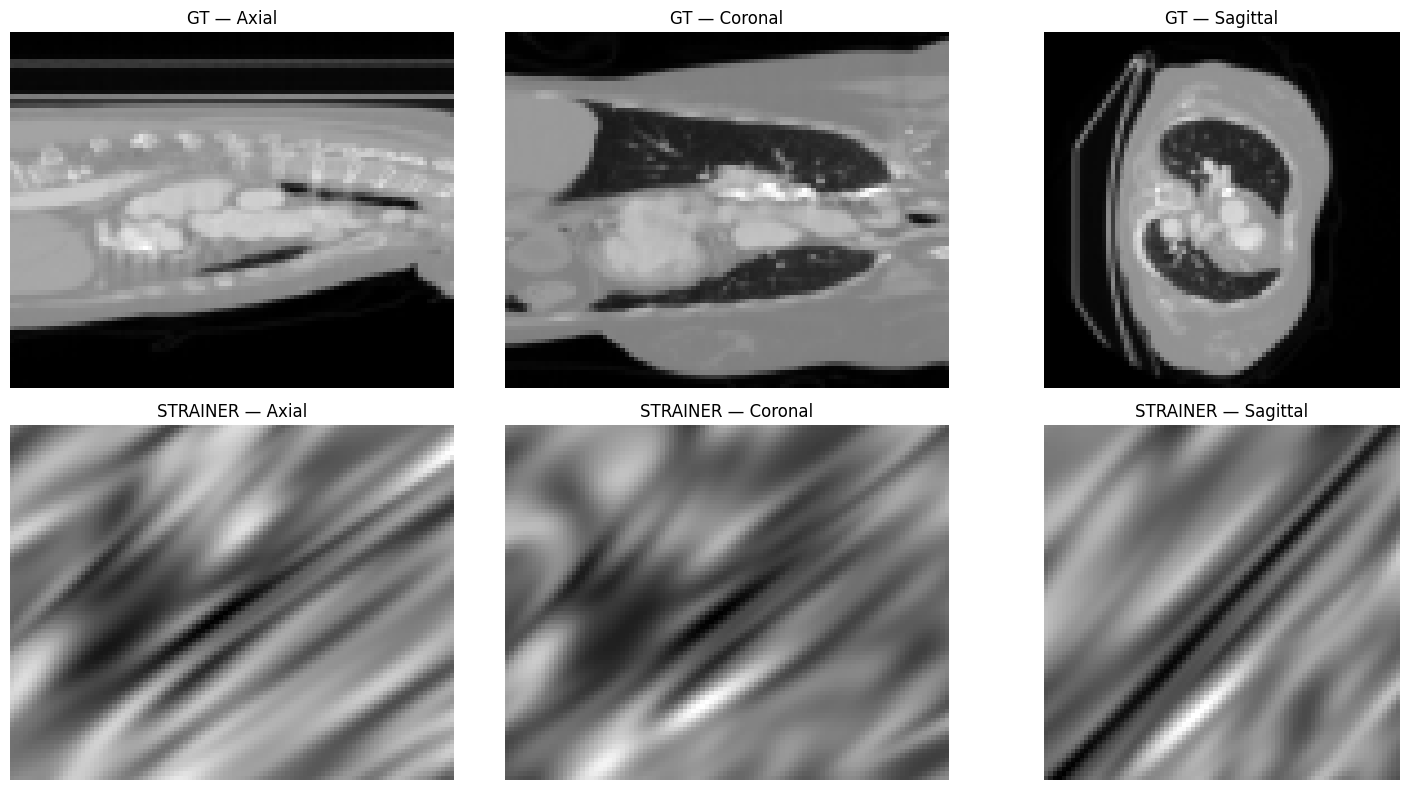

Figure saved as 'strainer_reconstruction_3views.png'


In [4]:


import os
import glob
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from skimage.transform import resize
from copy import deepcopy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------
# Corrected SineLayer
# -------------------------------
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30):
        super().__init__()
        self.in_features = in_features      # store for later use
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self._init_weights()

    def _init_weights(self):
        with torch.no_grad():
            if self.is_first:
                # For first layer, initialize weights uniformly in [-1/in_features, 1/in_features]
                bound = 1 / self.in_features
                self.linear.weight.uniform_(-bound, bound)
            else:
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

# -------------------------------
# INR (Implicit Neural Representation)
# -------------------------------
class INR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, outermost_linear=True,
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        layers = []
        if hidden_layers > 0:
            layers.append(SineLayer(in_features, hidden_features,
                                    is_first=True, omega_0=first_omega_0))
            for _ in range(hidden_layers - 1):
                layers.append(SineLayer(hidden_features, hidden_features,
                                        is_first=False, omega_0=hidden_omega_0))
        if outermost_linear or hidden_layers == 0:
            final = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                bound = np.sqrt(6 / hidden_features) / max(hidden_omega_0, 1e-12)
                final.weight.uniform_(-bound, bound)
            layers.append(final)
        else:
            layers.append(SineLayer(hidden_features, out_features,
                                    is_first=False, omega_0=hidden_omega_0))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# -------------------------------
# SharedINR (STRAINER backbone)
# -------------------------------
class SharedINR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, shared_encoder_layers=5, num_decoders=10):
        super().__init__()
        self.shared_encoder_layers = shared_encoder_layers
        self.num_decoders = num_decoders
        self.encoderINR = INR(
            in_features=in_features, hidden_features=hidden_features,
            hidden_layers=shared_encoder_layers - 1,
            out_features=hidden_features, outermost_linear=False)
        num_decoder_layers = hidden_layers - shared_encoder_layers
        self.decoderINRs = nn.ModuleList([
            INR(in_features=hidden_features, hidden_features=hidden_features,
                hidden_layers=num_decoder_layers - 1, out_features=out_features,
                outermost_linear=True)
            for _ in range(num_decoders)])

    def forward(self, coords):
        features = self.encoderINR(coords)
        return [decoder(features) for decoder in self.decoderINRs]

# -------------------------------
# STRAINER Encoder (produces latent vector)
# -------------------------------
class STRAINEREncoder(nn.Module):
    def __init__(self, hidden_features=256, shared_encoder_layers=5,
                 total_layers=6, in_channels=1, latent_dim=512,
                 num_train_decoders=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.strainer = SharedINR(
            in_features=3, hidden_features=hidden_features,
            hidden_layers=total_layers, out_features=in_channels,
            shared_encoder_layers=shared_encoder_layers,
            num_decoders=num_train_decoders)
        self.projection = nn.Sequential(
            nn.Linear(hidden_features, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, latent_dim))

    def _get_coords_3d(self, D, H, W, device):
        xs = torch.linspace(-1, 1, W, device=device)
        ys = torch.linspace(-1, 1, H, device=device)
        zs = torch.linspace(-1, 1, D, device=device)
        Z, Y, X = torch.meshgrid(zs, ys, xs, indexing='ij')
        coords = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=-1)
        return coords.unsqueeze(0)

    def encode(self, x):
        B, C, D, H, W = x.shape
        device = x.device
        coords = self._get_coords_3d(D, H, W, device)
        latents = []
        for i in range(B):
            features = self.strainer.encoderINR(coords)      # (1, N, hidden_features)
            pooled = features.mean(dim=1)                    # (1, hidden_features)
            z_i = self.projection(pooled)                    # (1, latent_dim)
            latents.append(z_i)
        return torch.cat(latents, dim=0)

# -------------------------------
# Decoder: Latent + coordinates -> voxel values
# -------------------------------
class LatentDecoderINR(nn.Module):
    def __init__(self, latent_dim=512, hidden_features=256, hidden_layers=4, out_features=1):
        super().__init__()
        self.fc_in = nn.Linear(3 + latent_dim, hidden_features)
        self.sines = nn.ModuleList()
        for _ in range(hidden_layers):
            self.sines.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=30))
        self.fc_out = nn.Linear(hidden_features, out_features)

    def forward(self, coords, latents):
        # coords: (N, 3), latents: (B, latent_dim)
        B, N = latents.shape[0], coords.shape[0]
        latents_exp = latents.unsqueeze(1).expand(-1, N, -1)   # (B, N, latent_dim)
        coords_exp = coords.unsqueeze(0).expand(B, -1, -1)     # (B, N, 3)
        x = torch.cat([coords_exp, latents_exp], dim=-1)       # (B, N, 3+latent_dim)
        x = self.fc_in(x)
        for layer in self.sines:
            x = layer(x)
        out = self.fc_out(x)                                   # (B, N, 1)
        return out.squeeze(-1)                                 # (B, N)

# -------------------------------
# Helper: load NIfTI volumes
# -------------------------------
def load_nifti_volumes(nifti_dir, num_volumes=5, target_shape=(80, 80, 100)):
    nii_files = sorted(glob.glob(os.path.join(nifti_dir, '**', '*.nii.gz'), recursive=True))
    print(f"Found {len(nii_files)} NIfTI files. Selecting {num_volumes}.")
    indices = np.linspace(0, len(nii_files)-1, num_volumes, dtype=int)
    selected = [nii_files[i] for i in indices]
    volumes = []
    for f in selected:
        img = nib.load(f)
        data = img.get_fdata().astype(np.float32)
        # Simple windowing to [-1000, 1000] then normalise to [0,1]
        data = np.clip(data, -1000, 1000)
        data = (data - data.min()) / (data.max() - data.min() + 1e-8)
        # Resize to target shape
        data = resize(data, target_shape, anti_aliasing=True)
        # Add channel dimension (C, D, H, W)
        data = torch.from_numpy(data).float().unsqueeze(0)   # (1, D, H, W)
        volumes.append(data)
    return volumes, target_shape

# -------------------------------
# Main reconstruction & visualisation
# -------------------------------
def main():
    # -------------------- User parameters --------------------
    # Change these paths to your Kaggle input directory
    NIFTI_DIR = "/kaggle/working/nifti"   # folder containing .nii.gz files
    ENCODER_WEIGHTS = "/kaggle/input/models/yvettetymz/strainer-encoder-3d-weights-pth/other/default/1/strainer_encoder_3d_weights.pth"
    NUM_VOLUMES = 3          # number of volumes to reconstruct (for visualisation)
    TARGET_SHAPE = (80, 80, 100)   # (D, H, W) as used in your pre-training
    # --------------------------------------------------------

    # Load volumes
    volumes, shape = load_nifti_volumes(NIFTI_DIR, num_volumes=NUM_VOLUMES, target_shape=TARGET_SHAPE)
    D, H, W = shape
    print(f"Volume shape: {D}x{H}x{W}")

    # Initialise encoder and load weights
    encoder = STRAINEREncoder(
        hidden_features=256, shared_encoder_layers=5,
        total_layers=6, in_channels=1, latent_dim=512,
        num_train_decoders=NUM_VOLUMES
    ).to(device)
    checkpoint = torch.load(ENCODER_WEIGHTS, map_location=device)
    encoder.strainer.encoderINR.load_state_dict(checkpoint['encoder_weights'])
    encoder.eval()
    print("Encoder loaded and set to eval mode.")

    # Generate latent vectors for all volumes
    latents = []
    with torch.no_grad():
        for vol in volumes:
            vol = vol.unsqueeze(0).to(device)   # (1,1,D,H,W)
            z = encoder.encode(vol)             # (1, latent_dim)
            latents.append(z)
    latents = torch.cat(latents, dim=0)          # (NUM_VOLUMES, latent_dim)
    print(f"Latent vectors computed: shape {latents.shape}")

    # Create coordinate grid for the target shape (flattened)
    xs = torch.linspace(-1, 1, W, device=device)
    ys = torch.linspace(-1, 1, H, device=device)
    zs = torch.linspace(-1, 1, D, device=device)
    Z, Y, X = torch.meshgrid(zs, ys, xs, indexing='ij')
    coords = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=-1)  # (N, 3)

    # Initialise and train decoder (or load pre-trained)
    decoder = LatentDecoderINR(latent_dim=512, hidden_features=256, hidden_layers=4).to(device)
    optim = torch.optim.Adam(decoder.parameters(), lr=1e-3)
    mse_loss = nn.MSELoss()

    print("Training decoder to reconstruct volumes from latents...")
    epochs = 200
    for epoch in range(epochs):
        total_loss = 0
        for i in range(NUM_VOLUMES):
            target = volumes[i].reshape(1, -1).to(device)   # (1, N)
            z_i = latents[i:i+1]                            # (1, latent_dim)
            pred = decoder(coords, z_i)                     # (1, N)
            loss = mse_loss(pred, target)
            optim.zero_grad()
            loss.backward()
            optim.step()
            total_loss += loss.item()
        if epoch % 50 == 0:
            print(f"Epoch {epoch:3d}, Loss: {total_loss/NUM_VOLUMES:.6f}")

    # Reconstruct all volumes using the trained decoder
    reconstructions = []
    with torch.no_grad():
        for i in range(NUM_VOLUMES):
            z_i = latents[i:i+1]
            pred_flat = decoder(coords, z_i)                # (1, N)
            recon = pred_flat.reshape(1, D, H, W)           # (1, D, H, W)
            reconstructions.append(recon)

    # Visualise for the first volume
    idx = 0
    gt = volumes[idx].cpu().numpy()[0]      # (D, H, W)
    recon = reconstructions[idx].cpu().numpy()[0]

    # Choose slice indices (middle of each dimension)
    ax_slice = D // 2
    cor_slice = H // 2
    sag_slice = W // 2

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    titles = [("GT — Axial", "GT — Coronal", "GT — Sagittal"),
              ("STRAINER — Axial", "STRAINER — Coronal", "STRAINER — Sagittal")]

    # GT row
    axes[0,0].imshow(gt[ax_slice, :, :], cmap='gray')
    axes[0,1].imshow(gt[:, cor_slice, :], cmap='gray')
    axes[0,2].imshow(gt[:, :, sag_slice], cmap='gray')
    # Reconstruction row
    axes[1,0].imshow(recon[ax_slice, :, :], cmap='gray')
    axes[1,1].imshow(recon[:, cor_slice, :], cmap='gray')
    axes[1,2].imshow(recon[:, :, sag_slice], cmap='gray')

    for i in range(2):
        for j in range(3):
            axes[i,j].set_title(titles[i][j])
            axes[i,j].axis('off')

    plt.tight_layout()
    plt.savefig("strainer_reconstruction_3views.png", dpi=150)
    plt.show()
    print("Figure saved as 'strainer_reconstruction_3views.png'")

if __name__ == "__main__":
    main()

Using device: cuda
Found 98 NIfTI files. Selecting 3.
Volume shape: 80x80x100
Encoder loaded and set to eval mode.
Latent vectors computed: shape torch.Size([3, 512])
Training decoder from scratch...
Epoch   0, Loss: 2.412032
Epoch  50, Loss: 0.181485
Epoch 100, Loss: 0.101500
Epoch 150, Loss: 0.072506
Decoder saved to /kaggle/working/decoder_weights.pth


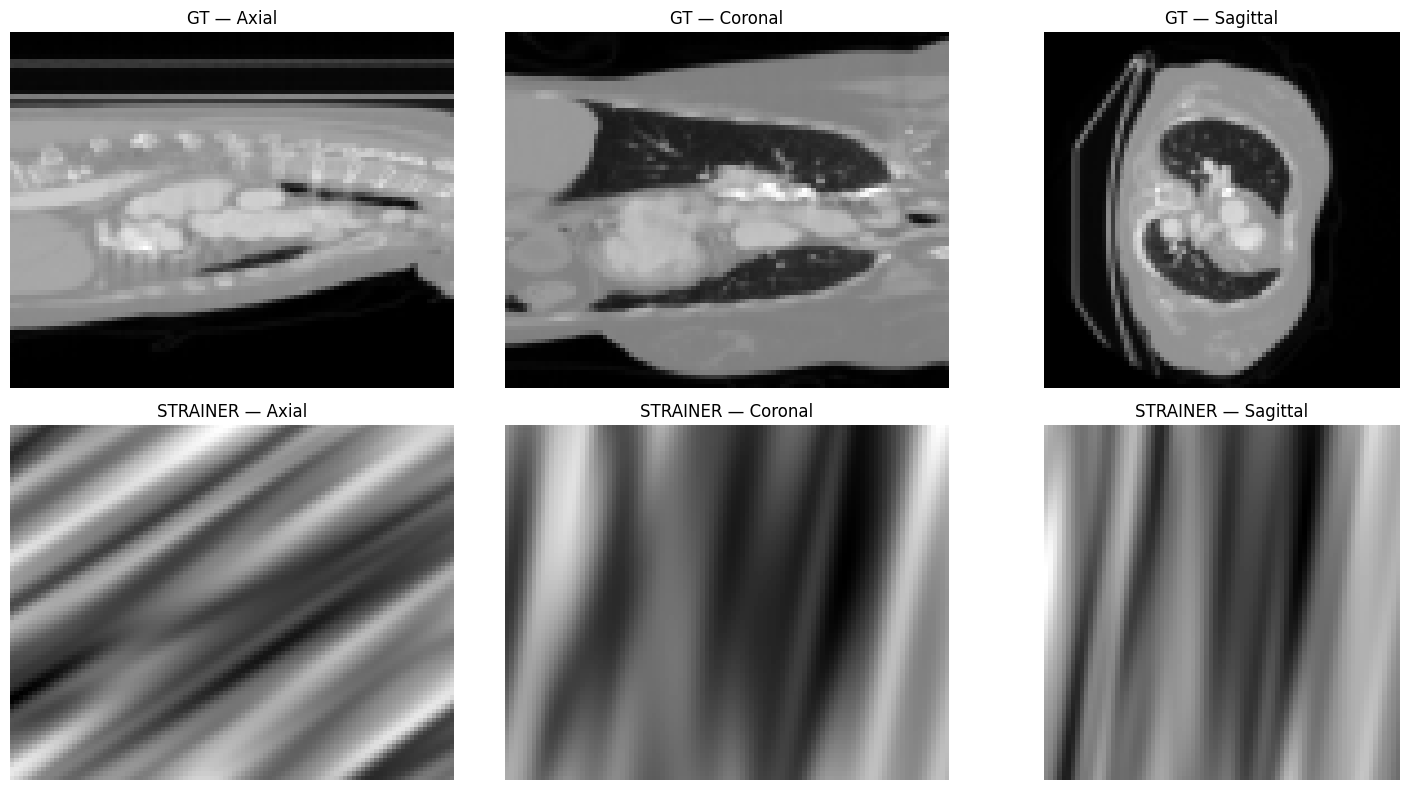

Figure saved as 'strainer_reconstruction_3views.png'


In [5]:
import os
import glob
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from skimage.transform import resize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------
# 1. Define the network components (SineLayer, INR, SharedINR, STRAINEREncoder, LatentDecoderINR)
# -------------------------------
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30):
        super().__init__()
        self.in_features = in_features
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self._init_weights()

    def _init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.in_features
                self.linear.weight.uniform_(-bound, bound)
            else:
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class INR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, outermost_linear=True,
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        layers = []
        if hidden_layers > 0:
            layers.append(SineLayer(in_features, hidden_features,
                                    is_first=True, omega_0=first_omega_0))
            for _ in range(hidden_layers - 1):
                layers.append(SineLayer(hidden_features, hidden_features,
                                        is_first=False, omega_0=hidden_omega_0))
        if outermost_linear or hidden_layers == 0:
            final = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                bound = np.sqrt(6 / hidden_features) / max(hidden_omega_0, 1e-12)
                final.weight.uniform_(-bound, bound)
            layers.append(final)
        else:
            layers.append(SineLayer(hidden_features, out_features,
                                    is_first=False, omega_0=hidden_omega_0))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class SharedINR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, shared_encoder_layers=5, num_decoders=10):
        super().__init__()
        self.shared_encoder_layers = shared_encoder_layers
        self.num_decoders = num_decoders
        self.encoderINR = INR(
            in_features=in_features, hidden_features=hidden_features,
            hidden_layers=shared_encoder_layers - 1,
            out_features=hidden_features, outermost_linear=False)
        num_decoder_layers = hidden_layers - shared_encoder_layers
        self.decoderINRs = nn.ModuleList([
            INR(in_features=hidden_features, hidden_features=hidden_features,
                hidden_layers=num_decoder_layers - 1, out_features=out_features,
                outermost_linear=True)
            for _ in range(num_decoders)])

    def forward(self, coords):
        features = self.encoderINR(coords)
        return [decoder(features) for decoder in self.decoderINRs]

class STRAINEREncoder(nn.Module):
    def __init__(self, hidden_features=256, shared_encoder_layers=5,
                 total_layers=6, in_channels=1, latent_dim=512,
                 num_train_decoders=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.strainer = SharedINR(
            in_features=3, hidden_features=hidden_features,
            hidden_layers=total_layers, out_features=in_channels,
            shared_encoder_layers=shared_encoder_layers,
            num_decoders=num_train_decoders)
        self.projection = nn.Sequential(
            nn.Linear(hidden_features, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, latent_dim))

    def _get_coords_3d(self, D, H, W, device):
        xs = torch.linspace(-1, 1, W, device=device)
        ys = torch.linspace(-1, 1, H, device=device)
        zs = torch.linspace(-1, 1, D, device=device)
        Z, Y, X = torch.meshgrid(zs, ys, xs, indexing='ij')
        coords = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=-1)
        return coords.unsqueeze(0)

    def encode(self, x):
        B, C, D, H, W = x.shape
        device = x.device
        coords = self._get_coords_3d(D, H, W, device)
        latents = []
        for i in range(B):
            features = self.strainer.encoderINR(coords)
            pooled = features.mean(dim=1)
            z_i = self.projection(pooled)
            latents.append(z_i)
        return torch.cat(latents, dim=0)

class LatentDecoderINR(nn.Module):
    def __init__(self, latent_dim=512, hidden_features=256, hidden_layers=4, out_features=1):
        super().__init__()
        self.fc_in = nn.Linear(3 + latent_dim, hidden_features)
        self.sines = nn.ModuleList()
        for _ in range(hidden_layers):
            self.sines.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=30))
        self.fc_out = nn.Linear(hidden_features, out_features)

    def forward(self, coords, latents):
        B, N = latents.shape[0], coords.shape[0]
        latents_exp = latents.unsqueeze(1).expand(-1, N, -1)
        coords_exp = coords.unsqueeze(0).expand(B, -1, -1)
        x = torch.cat([coords_exp, latents_exp], dim=-1)
        x = self.fc_in(x)
        for layer in self.sines:
            x = layer(x)
        out = self.fc_out(x)
        return out.squeeze(-1)

# -------------------------------
# 2. Helper: load NIfTI volumes
# -------------------------------
def load_nifti_volumes(nifti_dir, num_volumes=3, target_shape=(80, 80, 100)):
    nii_files = sorted(glob.glob(os.path.join(nifti_dir, '**', '*.nii.gz'), recursive=True))
    if len(nii_files) == 0:
        raise FileNotFoundError(f"No .nii.gz files found in {nifti_dir}")
    print(f"Found {len(nii_files)} NIfTI files. Selecting {num_volumes}.")
    indices = np.linspace(0, len(nii_files)-1, num_volumes, dtype=int)
    selected = [nii_files[i] for i in indices]
    volumes = []
    for f in selected:
        img = nib.load(f)
        data = img.get_fdata().astype(np.float32)
        data = np.clip(data, -1000, 1000)
        data = (data - data.min()) / (data.max() - data.min() + 1e-8)
        data = resize(data, target_shape, anti_aliasing=True)
        data = torch.from_numpy(data).float().unsqueeze(0)  # (1, D, H, W)
        volumes.append(data)
    return volumes, target_shape

# -------------------------------
# 3. Main function
# -------------------------------
def main():
    # ====== USER: UPDATE THESE PATHS ======
    NIFTI_DIR = "/kaggle/working/nifti"   # where your .nii.gz files are
    ENCODER_WEIGHTS = "/kaggle/input/models/yvettetymz/strainer-encoder-3d-weights-pth/other/default/1/strainer_encoder_3d_weights.pth"
    DECODER_WEIGHTS = "/kaggle/working/decoder_weights.pth"   # where to save/load decoder
    NUM_VOLUMES = 3
    TARGET_SHAPE = (80, 80, 100)
    # ======================================

    # Load volumes
    volumes, shape = load_nifti_volumes(NIFTI_DIR, NUM_VOLUMES, TARGET_SHAPE)
    D, H, W = shape
    print(f"Volume shape: {D}x{H}x{W}")

    # Load encoder
    encoder = STRAINEREncoder(
        hidden_features=256, shared_encoder_layers=5,
        total_layers=6, in_channels=1, latent_dim=512,
        num_train_decoders=NUM_VOLUMES
    ).to(device)
    checkpoint = torch.load(ENCODER_WEIGHTS, map_location=device)
    encoder.strainer.encoderINR.load_state_dict(checkpoint['encoder_weights'])
    encoder.eval()
    print("Encoder loaded and set to eval mode.")

    # Compute latents
    latents = []
    with torch.no_grad():
        for vol in volumes:
            vol = vol.unsqueeze(0).to(device)
            z = encoder.encode(vol)
            latents.append(z)
    latents = torch.cat(latents, dim=0)
    print(f"Latent vectors computed: shape {latents.shape}")

    # Create coordinate grid
    xs = torch.linspace(-1, 1, W, device=device)
    ys = torch.linspace(-1, 1, H, device=device)
    zs = torch.linspace(-1, 1, D, device=device)
    Z, Y, X = torch.meshgrid(zs, ys, xs, indexing='ij')
    coords = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=-1)

    # Decoder: try to load existing weights, otherwise train from scratch
    decoder = LatentDecoderINR(latent_dim=512, hidden_features=256, hidden_layers=4).to(device)
    if os.path.exists(DECODER_WEIGHTS):
        print(f"Loading pre-trained decoder from {DECODER_WEIGHTS}")
        decoder.load_state_dict(torch.load(DECODER_WEIGHTS, map_location=device))
    else:
        print("Training decoder from scratch...")
        optim = torch.optim.Adam(decoder.parameters(), lr=1e-3)
        mse_loss = nn.MSELoss()
        epochs = 200
        for epoch in range(epochs):
            total_loss = 0
            for i in range(NUM_VOLUMES):
                target = volumes[i].reshape(1, -1).to(device)
                z_i = latents[i:i+1]
                pred = decoder(coords, z_i)
                loss = mse_loss(pred, target)
                optim.zero_grad()
                loss.backward()
                optim.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch:3d}, Loss: {total_loss/NUM_VOLUMES:.6f}")
        torch.save(decoder.state_dict(), DECODER_WEIGHTS)
        print(f"Decoder saved to {DECODER_WEIGHTS}")

    # Reconstruct all volumes
    reconstructions = []
    with torch.no_grad():
        for i in range(NUM_VOLUMES):
            z_i = latents[i:i+1]
            pred_flat = decoder(coords, z_i)
            recon = pred_flat.reshape(1, D, H, W)
            reconstructions.append(recon)

    # Visualise first volume
    idx = 0
    gt = volumes[idx].cpu().numpy()[0]
    recon = reconstructions[idx].cpu().numpy()[0]

    ax_slice = D // 2
    cor_slice = H // 2
    sag_slice = W // 2

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    titles = [("GT — Axial", "GT — Coronal", "GT — Sagittal"),
              ("STRAINER — Axial", "STRAINER — Coronal", "STRAINER — Sagittal")]

    # Ground truth row
    axes[0,0].imshow(gt[ax_slice, :, :], cmap='gray')
    axes[0,1].imshow(gt[:, cor_slice, :], cmap='gray')
    axes[0,2].imshow(gt[:, :, sag_slice], cmap='gray')
    # Reconstruction row
    axes[1,0].imshow(recon[ax_slice, :, :], cmap='gray')
    axes[1,1].imshow(recon[:, cor_slice, :], cmap='gray')
    axes[1,2].imshow(recon[:, :, sag_slice], cmap='gray')

    for i in range(2):
        for j in range(3):
            axes[i,j].set_title(titles[i][j])
            axes[i,j].axis('off')

    plt.tight_layout()
    plt.savefig("strainer_reconstruction_3views.png", dpi=150)
    plt.show()
    print("Figure saved as 'strainer_reconstruction_3views.png'")

if __name__ == "__main__":
    main()

Using device: cuda
Found 98 NIfTI files. Selecting 3.
Volume shape: 80x80x100
Encoder loaded, frozen, and set to eval mode.
Latent vectors computed: shape torch.Size([3, 512])
Loading pre‑trained decoder from /kaggle/working/decoder_weights.pth


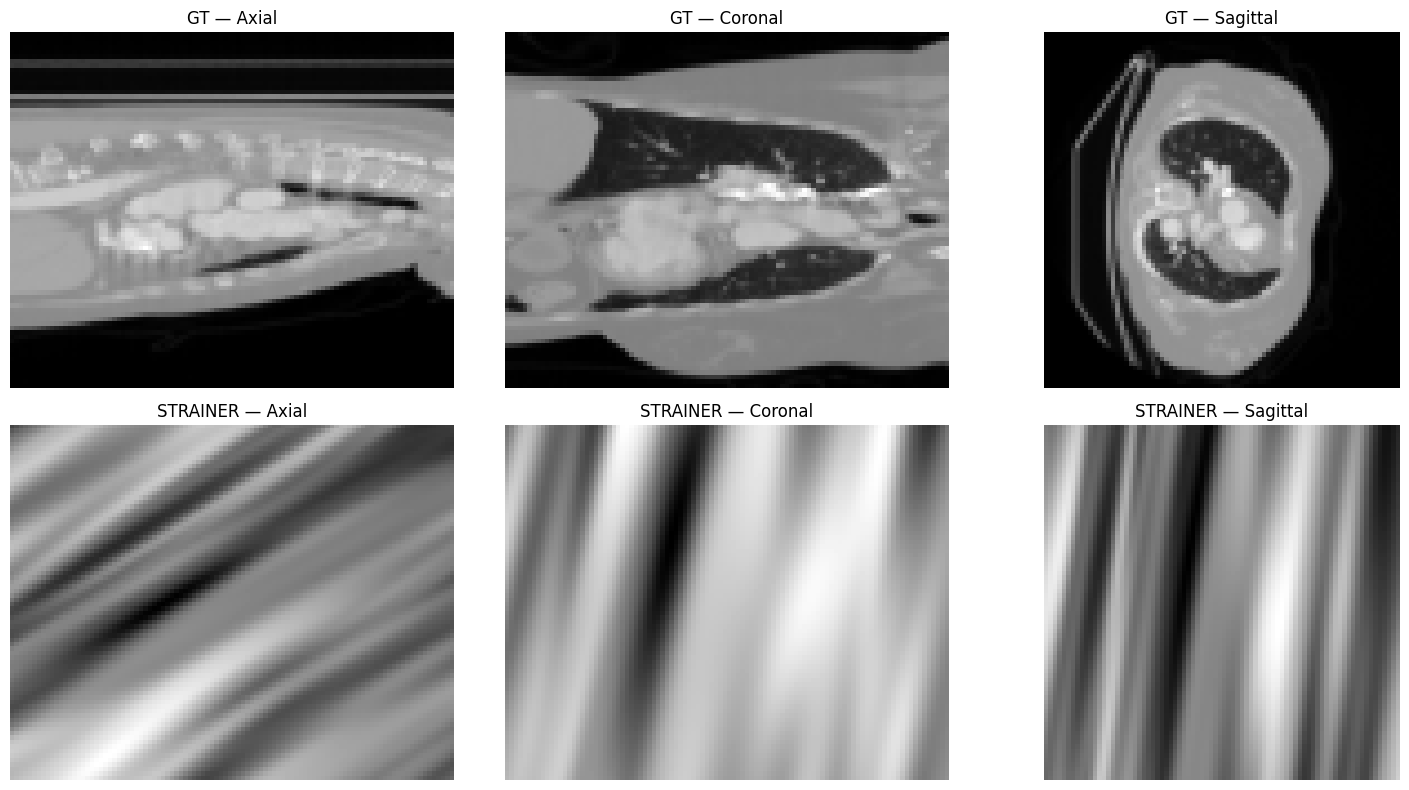

Figure saved as 'strainer_reconstruction_3views.png'


In [6]:
import os
import glob
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from skimage.transform import resize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 1. Define all network components (SineLayer, INR, SharedINR,
#    STRAINEREncoder, LatentDecoderINR)
# ----------------------------------------------------------------------
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30):
        super().__init__()
        self.in_features = in_features
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self._init_weights()

    def _init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.in_features
                self.linear.weight.uniform_(-bound, bound)
            else:
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class INR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, outermost_linear=True,
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        layers = []
        if hidden_layers > 0:
            layers.append(SineLayer(in_features, hidden_features,
                                    is_first=True, omega_0=first_omega_0))
            for _ in range(hidden_layers - 1):
                layers.append(SineLayer(hidden_features, hidden_features,
                                        is_first=False, omega_0=hidden_omega_0))
        if outermost_linear or hidden_layers == 0:
            final = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                bound = np.sqrt(6 / hidden_features) / max(hidden_omega_0, 1e-12)
                final.weight.uniform_(-bound, bound)
            layers.append(final)
        else:
            layers.append(SineLayer(hidden_features, out_features,
                                    is_first=False, omega_0=hidden_omega_0))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class SharedINR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, shared_encoder_layers=5, num_decoders=10):
        super().__init__()
        self.shared_encoder_layers = shared_encoder_layers
        self.num_decoders = num_decoders
        self.encoderINR = INR(
            in_features=in_features, hidden_features=hidden_features,
            hidden_layers=shared_encoder_layers - 1,
            out_features=hidden_features, outermost_linear=False)
        num_decoder_layers = hidden_layers - shared_encoder_layers
        self.decoderINRs = nn.ModuleList([
            INR(in_features=hidden_features, hidden_features=hidden_features,
                hidden_layers=num_decoder_layers - 1, out_features=out_features,
                outermost_linear=True)
            for _ in range(num_decoders)])

    def forward(self, coords):
        features = self.encoderINR(coords)
        return [decoder(features) for decoder in self.decoderINRs]

class STRAINEREncoder(nn.Module):
    def __init__(self, hidden_features=256, shared_encoder_layers=5,
                 total_layers=6, in_channels=1, latent_dim=512,
                 num_train_decoders=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.strainer = SharedINR(
            in_features=3, hidden_features=hidden_features,
            hidden_layers=total_layers, out_features=in_channels,
            shared_encoder_layers=shared_encoder_layers,
            num_decoders=num_train_decoders)
        self.projection = nn.Sequential(
            nn.Linear(hidden_features, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, latent_dim))

    def _get_coords_3d(self, D, H, W, device):
        xs = torch.linspace(-1, 1, W, device=device)
        ys = torch.linspace(-1, 1, H, device=device)
        zs = torch.linspace(-1, 1, D, device=device)
        Z, Y, X = torch.meshgrid(zs, ys, xs, indexing='ij')
        coords = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=-1)
        return coords.unsqueeze(0)

    def encode(self, x):
        B, C, D, H, W = x.shape
        device = x.device
        coords = self._get_coords_3d(D, H, W, device)
        latents = []
        for i in range(B):
            features = self.strainer.encoderINR(coords)      # (1, N, hidden_features)
            pooled = features.mean(dim=1)                    # (1, hidden_features)
            z_i = self.projection(pooled)                    # (1, latent_dim)
            latents.append(z_i)
        return torch.cat(latents, dim=0)

class LatentDecoderINR(nn.Module):
    def __init__(self, latent_dim=512, hidden_features=256, hidden_layers=4, out_features=1):
        super().__init__()
        self.fc_in = nn.Linear(3 + latent_dim, hidden_features)
        self.sines = nn.ModuleList()
        for _ in range(hidden_layers):
            self.sines.append(SineLayer(hidden_features, hidden_features, is_first=False, omega_0=30))
        self.fc_out = nn.Linear(hidden_features, out_features)

    def forward(self, coords, latents):
        B, N = latents.shape[0], coords.shape[0]
        latents_exp = latents.unsqueeze(1).expand(-1, N, -1)
        coords_exp = coords.unsqueeze(0).expand(B, -1, -1)
        x = torch.cat([coords_exp, latents_exp], dim=-1)
        x = self.fc_in(x)
        for layer in self.sines:
            x = layer(x)
        out = self.fc_out(x)
        return out.squeeze(-1)

# ----------------------------------------------------------------------
# 2. Helper: load NIfTI volumes
# ----------------------------------------------------------------------
def load_nifti_volumes(nifti_dir, num_volumes=3, target_shape=(80, 80, 100)):
    nii_files = sorted(glob.glob(os.path.join(nifti_dir, '**', '*.nii.gz'), recursive=True))
    if len(nii_files) == 0:
        raise FileNotFoundError(f"No .nii.gz files found in {nifti_dir}")
    print(f"Found {len(nii_files)} NIfTI files. Selecting {num_volumes}.")
    indices = np.linspace(0, len(nii_files)-1, num_volumes, dtype=int)
    selected = [nii_files[i] for i in indices]
    volumes = []
    for f in selected:
        img = nib.load(f)
        data = img.get_fdata().astype(np.float32)
        data = np.clip(data, -1000, 1000)
        data = (data - data.min()) / (data.max() - data.min() + 1e-8)
        data = resize(data, target_shape, anti_aliasing=True)
        data = torch.from_numpy(data).float().unsqueeze(0)  # (1, D, H, W)
        volumes.append(data)
    return volumes, target_shape


# ----------------------------------------------------------------------
# 3. Main: freeze encoder, load weights, train decoder (once), reconstruct
# ----------------------------------------------------------------------
def main():
    # ====================== ADJUST THESE PATHS ======================
    NIFTI_DIR = "/kaggle/working/nifti"                     # folder with .nii.gz files
    ENCODER_WEIGHTS = "/kaggle/input/models/yvettetymz/strainer-encoder-3d-weights-pth/other/default/1/strainer_encoder_3d_weights.pth"  # path to pre-trained encoder
    DECODER_WEIGHTS = "/kaggle/working/decoder_weights.pth"     # where to save/load decoder
    NUM_VOLUMES = 3
    TARGET_SHAPE = (80, 80, 100)
    # ================================================================

    # Load volumes
    volumes, shape = load_nifti_volumes(NIFTI_DIR, NUM_VOLUMES, TARGET_SHAPE)
    D, H, W = shape
    print(f"Volume shape: {D}x{H}x{W}")

    # Initialise encoder and load weights
    encoder = STRAINEREncoder(
        hidden_features=256, shared_encoder_layers=5,
        total_layers=6, in_channels=1, latent_dim=512,
        num_train_decoders=NUM_VOLUMES
    ).to(device)

    checkpoint = torch.load(ENCODER_WEIGHTS, map_location=device)
    encoder.strainer.encoderINR.load_state_dict(checkpoint['encoder_weights'])
    # FREEZE encoder – no gradients
    for param in encoder.parameters():
        param.requires_grad = False
    encoder.eval()
    print("Encoder loaded, frozen, and set to eval mode.")

    # Compute latent vectors for all volumes (no gradients)
    latents = []
    with torch.no_grad():
        for vol in volumes:
            vol = vol.unsqueeze(0).to(device)   # (1,1,D,H,W)
            z = encoder.encode(vol)             # (1, latent_dim)
            latents.append(z)
    latents = torch.cat(latents, dim=0)          # (NUM_VOLUMES, latent_dim)
    print(f"Latent vectors computed: shape {latents.shape}")

    # Create coordinate grid for the target shape
    xs = torch.linspace(-1, 1, W, device=device)
    ys = torch.linspace(-1, 1, H, device=device)
    zs = torch.linspace(-1, 1, D, device=device)
    Z, Y, X = torch.meshgrid(zs, ys, xs, indexing='ij')
    coords = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=-1)  # (N,3)

    # Decoder: try to load pre‑trained, otherwise train from scratch
    decoder = LatentDecoderINR(latent_dim=512, hidden_features=256, hidden_layers=4).to(device)
    if os.path.exists(DECODER_WEIGHTS):
        print(f"Loading pre‑trained decoder from {DECODER_WEIGHTS}")
        decoder.load_state_dict(torch.load(DECODER_WEIGHTS, map_location=device))
        decoder.eval()
    else:
        print("Training decoder from scratch (encoder is frozen)...")
        optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3)
        mse_loss = nn.MSELoss()
        epochs = 200
        for epoch in range(epochs):
            total_loss = 0
            for i in range(NUM_VOLUMES):
                target = volumes[i].reshape(1, -1).to(device)   # (1, N)
                z_i = latents[i:i+1]                            # (1, latent_dim)
                pred = decoder(coords, z_i)                     # (1, N)
                loss = mse_loss(pred, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch:3d}, Loss: {total_loss/NUM_VOLUMES:.6f}")
        torch.save(decoder.state_dict(), DECODER_WEIGHTS)
        print(f"Decoder saved to {DECODER_WEIGHTS}")
        decoder.eval()

    # Reconstruct all volumes using the trained decoder
    reconstructions = []
    with torch.no_grad():
        for i in range(NUM_VOLUMES):
            z_i = latents[i:i+1]
            pred_flat = decoder(coords, z_i)                # (1, N)
            recon = pred_flat.reshape(1, D, H, W)           # (1, D, H, W)
            reconstructions.append(recon)

    # Visualise the first volume (Ground Truth vs Reconstruction)
    idx = 0
    gt = volumes[idx].cpu().numpy()[0]      # (D, H, W)
    recon = reconstructions[idx].cpu().numpy()[0]

    ax_slice = D // 2
    cor_slice = H // 2
    sag_slice = W // 2

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    titles = [("GT — Axial", "GT — Coronal", "GT — Sagittal"),
              ("STRAINER — Axial", "STRAINER — Coronal", "STRAINER — Sagittal")]

    # Ground truth row
    axes[0,0].imshow(gt[ax_slice, :, :], cmap='gray')
    axes[0,1].imshow(gt[:, cor_slice, :], cmap='gray')
    axes[0,2].imshow(gt[:, :, sag_slice], cmap='gray')
    # Reconstruction row
    axes[1,0].imshow(recon[ax_slice, :, :], cmap='gray')
    axes[1,1].imshow(recon[:, cor_slice, :], cmap='gray')
    axes[1,2].imshow(recon[:, :, sag_slice], cmap='gray')

    for i in range(2):
        for j in range(3):
            axes[i,j].set_title(titles[i][j])
            axes[i,j].axis('off')

    plt.tight_layout()
    plt.savefig("strainer_reconstruction_3views.png", dpi=150)
    plt.show()
    print("Figure saved as 'strainer_reconstruction_3views.png'")

if __name__ == "__main__":
    main()

In [ ]:
! import os
import glob
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchio as tio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 1. STRAINER encoder components (unchanged)
# ----------------------------------------------------------------------
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30):
        super().__init__()
        self.in_features = in_features
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self._init_weights()

    def _init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.in_features
                self.linear.weight.uniform_(-bound, bound)
            else:
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class INR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, outermost_linear=True,
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        layers = []
        if hidden_layers > 0:
            layers.append(SineLayer(in_features, hidden_features,
                                    is_first=True, omega_0=first_omega_0))
            for _ in range(hidden_layers - 1):
                layers.append(SineLayer(hidden_features, hidden_features,
                                        is_first=False, omega_0=hidden_omega_0))
        if outermost_linear or hidden_layers == 0:
            final = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                bound = np.sqrt(6 / hidden_features) / max(hidden_omega_0, 1e-12)
                final.weight.uniform_(-bound, bound)
            layers.append(final)
        else:
            layers.append(SineLayer(hidden_features, out_features,
                                    is_first=False, omega_0=hidden_omega_0))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class SharedINR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, shared_encoder_layers=5, num_decoders=10):
        super().__init__()
        self.shared_encoder_layers = shared_encoder_layers
        self.num_decoders = num_decoders
        self.encoderINR = INR(
            in_features=in_features, hidden_features=hidden_features,
            hidden_layers=shared_encoder_layers - 1,
            out_features=hidden_features, outermost_linear=False)
        num_decoder_layers = hidden_layers - shared_encoder_layers
        self.decoderINRs = nn.ModuleList([
            INR(in_features=hidden_features, hidden_features=hidden_features,
                hidden_layers=num_decoder_layers - 1, out_features=out_features,
                outermost_linear=True)
            for _ in range(num_decoders)])

    def forward(self, coords):
        features = self.encoderINR(coords)
        return [decoder(features) for decoder in self.decoderINRs]

class STRAINEREncoder(nn.Module):
    def __init__(self, hidden_features=256, shared_encoder_layers=5,
                 total_layers=6, in_channels=1, latent_dim=512,
                 num_train_decoders=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.strainer = SharedINR(
            in_features=3, hidden_features=hidden_features,
            hidden_layers=total_layers, out_features=in_channels,
            shared_encoder_layers=shared_encoder_layers,
            num_decoders=num_train_decoders)
        self.projection = nn.Sequential(
            nn.Linear(hidden_features, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, latent_dim))

    def _get_coords_3d(self, D, H, W, device):
        xs = torch.linspace(-1, 1, W, device=device)
        ys = torch.linspace(-1, 1, H, device=device)
        zs = torch.linspace(-1, 1, D, device=device)
        Z, Y, X = torch.meshgrid(zs, ys, xs, indexing='ij')
        coords = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=-1)
        return coords.unsqueeze(0)

    def encode(self, x):
        B, C, D, H, W = x.shape
        device = x.device
        coords = self._get_coords_3d(D, H, W, device)
        latents = []
        for i in range(B):
            features = self.strainer.encoderINR(coords)
            pooled = features.mean(dim=1)
            z_i = self.projection(pooled)
            latents.append(z_i)
        return torch.cat(latents, dim=0)

# ----------------------------------------------------------------------
# 2. CNN Decoder (adapts to any cubic target shape)
# ----------------------------------------------------------------------
class CNN3DDecoder(nn.Module):
    def __init__(self, latent_dim=512, target_size=224, base_filters=64):
        """
        target_size: desired cubic volume size (e.g., 224)
        """
        super().__init__()
        self.target_size = target_size
        # We'll use a fixed small grid size that upsamples to target_size
        # Choose initial grid size so that after upsampling we reach target_size
        # Use 4 upsampling blocks: 14 -> 28 -> 56 -> 112 -> 224 (if target 224)
        # initial_size = target_size // 16 (since 2^4=16)
        init_size = target_size // 16
        self.init_size = init_size
        self.fc = nn.Linear(latent_dim, base_filters * 8 * init_size * init_size * init_size)
        self.upsample = nn.Sequential(
            nn.ConvTranspose3d(base_filters * 8, base_filters * 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(base_filters * 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose3d(base_filters * 4, base_filters * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(base_filters * 2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose3d(base_filters * 2, base_filters, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(base_filters),
            nn.ReLU(inplace=True),
            nn.ConvTranspose3d(base_filters, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
        # After 4 upsamplings: init_size * 2^4 = init_size*16 = target_size
        # No padding needed because we exactly match the target cubic size.

    def forward(self, latents):
        B = latents.shape[0]
        x = self.fc(latents)   # (B, base_filters*8 * init_size^3)
        x = x.view(B, -1, self.init_size, self.init_size, self.init_size)
        x = self.upsample(x)   # (B, 1, target_size, target_size, target_size)
        return x

# ----------------------------------------------------------------------
# 3. Load NIfTI volumes using TorchIO with isotropic resampling and resize to cubic
# ----------------------------------------------------------------------
def load_nifti_volumes_torchio(nifti_dir, num_volumes=3, input_size=224):
    """
    - Resample to isotropic 1mm spacing
    - Resize (crop/pad) to cubic volume of size (input_size, input_size, input_size)
    - Clip CT values to [-1000, 1000] and normalize to [0,1]
    """
    nii_files = sorted(glob.glob(os.path.join(nifti_dir, '**', '*.nii.gz'), recursive=True))
    if len(nii_files) == 0:
        raise FileNotFoundError(f"No .nii.gz files found in {nifti_dir}")
    print(f"Found {len(nii_files)} NIfTI files. Selecting {num_volumes}.")
    indices = np.linspace(0, len(nii_files)-1, num_volumes, dtype=int)
    selected = [nii_files[i] for i in indices]

    target_shape = (input_size, input_size, input_size)  # (D, H, W)

    # Define TorchIO transforms
    preprocess = tio.Compose([
        tio.Resample(target_spacing=(1, 1, 1)),           # isotropic 1mm
        tio.CropOrPad(target_shape),                     # force to exact cubic shape
        tio.Clamp(out_min=-1000, out_max=1000),          # CT window
        tio.RescaleIntensity(out_min_max=(0, 1)),        # normalize to [0,1]
        tio.ToType(tio.DATA, torch.float32),
    ])

    volumes = []
    for f in selected:
        subject = tio.Subject(ct=tio.ScalarImage(f))
        transformed = preprocess(subject)
        tensor = transformed.ct.data                     # (1, D, H, W)
        volumes.append(tensor.squeeze(0))                # (D, H, W) - we'll add channel later
    return volumes, target_shape

# ----------------------------------------------------------------------
# 4. Main: freeze encoder, train CNN decoder, reconstruct
# ----------------------------------------------------------------------
def main():
    # ====================== ADJUST THESE PATHS ======================
    NIFTI_DIR = "/kaggle/working/nifti"
    ENCODER_WEIGHTS = "/kaggle/input/models/yvettetymz/strainer-encoder-3d-weights-pth/other/default/1/strainer_encoder_3d_weights.pth"
    DECODER_WEIGHTS = "/kaggle/working/cnn_decoder_weights.pth"
    NUM_VOLUMES = 3
    INPUT_SIZE = 224           # cubic volume size (default 224)
    # ================================================================

    # Load volumes (each as (D, H, W) without channel)
    volumes, target_shape = load_nifti_volumes_torchio(NIFTI_DIR, NUM_VOLUMES, INPUT_SIZE)
    D, H, W = target_shape
    print(f"Volume shape after preprocessing: {D}x{H}x{W} (cubic)")

    # Add channel dimension -> (1, D, H, W)
    volumes = [vol.unsqueeze(0) for vol in volumes]   # each (1, D, H, W)

    # Encoder (frozen)
    encoder = STRAINEREncoder(
        hidden_features=256, shared_encoder_layers=5,
        total_layers=6, in_channels=1, latent_dim=512,
        num_train_decoders=NUM_VOLUMES
    ).to(device)
    checkpoint = torch.load(ENCODER_WEIGHTS, map_location=device)
    encoder.strainer.encoderINR.load_state_dict(checkpoint['encoder_weights'])
    for param in encoder.parameters():
        param.requires_grad = False
    encoder.eval()
    print("Encoder loaded and frozen.")

    # Compute latent vectors
    latents = []
    with torch.no_grad():
        for vol in volumes:
            vol_batch = vol.unsqueeze(0).to(device)   # (1,1,D,H,W)
            z = encoder.encode(vol_batch)             # (1, latent_dim)
            latents.append(z)
    latents = torch.cat(latents, dim=0)               # (NUM_VOLUMES, latent_dim)
    print(f"Latents shape: {latents.shape}")

    # Decoder (CNN) with cubic target size
    decoder = CNN3DDecoder(latent_dim=512, target_size=INPUT_SIZE, base_filters=64).to(device)

    # Load or train decoder
    if os.path.exists(DECODER_WEIGHTS):
        print("Loading pre-trained CNN decoder...")
        decoder.load_state_dict(torch.load(DECODER_WEIGHTS, map_location=device))
        decoder.eval()
    else:
        print("Training CNN decoder from scratch (encoder frozen)...")
        optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3)
        mse_loss = nn.MSELoss()
        epochs = 200
        for epoch in range(epochs):
            total_loss = 0
            for i in range(NUM_VOLUMES):
                target = volumes[i].unsqueeze(0).to(device)   # (1,1,D,H,W)
                z_i = latents[i:i+1]                         # (1,512)
                recon = decoder(z_i)                         # (1,1,D,H,W)
                loss = mse_loss(recon, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch:3d}, Loss: {total_loss/NUM_VOLUMES:.6f}")
        torch.save(decoder.state_dict(), DECODER_WEIGHTS)
        print(f"Decoder saved to {DECODER_WEIGHTS}")
        decoder.eval()

    # Reconstruct all volumes
    reconstructions = []
    with torch.no_grad():
        for i in range(NUM_VOLUMES):
            z_i = latents[i:i+1]
            recon = decoder(z_i)          # (1,1,D,H,W)
            reconstructions.append(recon.squeeze(0).squeeze(0))  # (D,H,W)

    # Visualise first volume
    idx = 0
    gt = volumes[idx].squeeze(0).cpu().numpy()  # (D,H,W)
    recon = reconstructions[idx].cpu().numpy()

    # Use middle slices
    ax_slice = D // 2
    cor_slice = H // 2
    sag_slice = W // 2

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    titles = [("GT — Axial", "GT — Coronal", "GT — Sagittal"),
              ("STRAINER — Axial", "STRAINER — Coronal", "STRAINER — Sagittal")]

    axes[0,0].imshow(gt[ax_slice, :, :], cmap='gray')
    axes[0,1].imshow(gt[:, cor_slice, :], cmap='gray')
    axes[0,2].imshow(gt[:, :, sag_slice], cmap='gray')
    axes[1,0].imshow(recon[ax_slice, :, :], cmap='gray')
    axes[1,1].imshow(recon[:, cor_slice, :], cmap='gray')
    axes[1,2].imshow(recon[:, :, sag_slice], cmap='gray')

    for i in range(2):
        for j in range(3):
            axes[i,j].set_title(titles[i][j])
            axes[i,j].axis('off')

    plt.tight_layout()
    plt.savefig(f"reconstruction_{INPUT_SIZE}cubic.png", dpi=150)
    plt.show()
    print(f"Reconstruction saved for input_size={INPUT_SIZE}.")

if __name__ == "__main__":
    main()

In [2]:
!pip install torchio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.5/199.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.6 MB/s eta 0:00:00


In [3]:

import os
import glob
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchio as tio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 1. STRAINER encoder components (unchanged)
# ----------------------------------------------------------------------
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30):
        super().__init__()
        self.in_features = in_features
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self._init_weights()

    def _init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1 / self.in_features
                self.linear.weight.uniform_(-bound, bound)
            else:
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

class INR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, outermost_linear=True,
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        layers = []
        if hidden_layers > 0:
            layers.append(SineLayer(in_features, hidden_features,
                                    is_first=True, omega_0=first_omega_0))
            for _ in range(hidden_layers - 1):
                layers.append(SineLayer(hidden_features, hidden_features,
                                        is_first=False, omega_0=hidden_omega_0))
        if outermost_linear or hidden_layers == 0:
            final = nn.Linear(hidden_features, out_features)
            with torch.no_grad():
                bound = np.sqrt(6 / hidden_features) / max(hidden_omega_0, 1e-12)
                final.weight.uniform_(-bound, bound)
            layers.append(final)
        else:
            layers.append(SineLayer(hidden_features, out_features,
                                    is_first=False, omega_0=hidden_omega_0))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class SharedINR(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, shared_encoder_layers=5, num_decoders=10):
        super().__init__()
        self.shared_encoder_layers = shared_encoder_layers
        self.num_decoders = num_decoders
        self.encoderINR = INR(
            in_features=in_features, hidden_features=hidden_features,
            hidden_layers=shared_encoder_layers - 1,
            out_features=hidden_features, outermost_linear=False)
        num_decoder_layers = hidden_layers - shared_encoder_layers
        self.decoderINRs = nn.ModuleList([
            INR(in_features=hidden_features, hidden_features=hidden_features,
                hidden_layers=num_decoder_layers - 1, out_features=out_features,
                outermost_linear=True)
            for _ in range(num_decoders)])

    def forward(self, coords):
        features = self.encoderINR(coords)
        return [decoder(features) for decoder in self.decoderINRs]

class STRAINEREncoder(nn.Module):
    def __init__(self, hidden_features=256, shared_encoder_layers=5,
                 total_layers=6, in_channels=1, latent_dim=512,
                 num_train_decoders=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.strainer = SharedINR(
            in_features=3, hidden_features=hidden_features,
            hidden_layers=total_layers, out_features=in_channels,
            shared_encoder_layers=shared_encoder_layers,
            num_decoders=num_train_decoders)
        self.projection = nn.Sequential(
            nn.Linear(hidden_features, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.GELU(),
            nn.Linear(latent_dim, latent_dim))

    def _get_coords_3d(self, D, H, W, device):
        xs = torch.linspace(-1, 1, W, device=device)
        ys = torch.linspace(-1, 1, H, device=device)
        zs = torch.linspace(-1, 1, D, device=device)
        Z, Y, X = torch.meshgrid(zs, ys, xs, indexing='ij')
        coords = torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=-1)
        return coords.unsqueeze(0)

    def encode(self, x):
        B, C, D, H, W = x.shape
        device = x.device
        coords = self._get_coords_3d(D, H, W, device)
        latents = []
        for i in range(B):
            features = self.strainer.encoderINR(coords)
            pooled = features.mean(dim=1)
            z_i = self.projection(pooled)
            latents.append(z_i)
        return torch.cat(latents, dim=0)

# ----------------------------------------------------------------------
# 2. CNN Decoder (adapts to any cubic target shape)
# ----------------------------------------------------------------------
class CNN3DDecoder(nn.Module):
    def __init__(self, latent_dim=512, target_size=224, base_filters=64):
        """
        target_size: desired cubic volume size (e.g., 224)
        """
        super().__init__()
        self.target_size = target_size
        # We'll use a fixed small grid size that upsamples to target_size
        # Choose initial grid size so that after upsampling we reach target_size
        # Use 4 upsampling blocks: 14 -> 28 -> 56 -> 112 -> 224 (if target 224)
        # initial_size = target_size // 16 (since 2^4=16)
        init_size = target_size // 16
        self.init_size = init_size
        self.fc = nn.Linear(latent_dim, base_filters * 8 * init_size * init_size * init_size)
        self.upsample = nn.Sequential(
            nn.ConvTranspose3d(base_filters * 8, base_filters * 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(base_filters * 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose3d(base_filters * 4, base_filters * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(base_filters * 2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose3d(base_filters * 2, base_filters, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(base_filters),
            nn.ReLU(inplace=True),
            nn.ConvTranspose3d(base_filters, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
        # After 4 upsamplings: init_size * 2^4 = init_size*16 = target_size
        # No padding needed because we exactly match the target cubic size.

    def forward(self, latents):
        B = latents.shape[0]
        x = self.fc(latents)   # (B, base_filters*8 * init_size^3)
        x = x.view(B, -1, self.init_size, self.init_size, self.init_size)
        x = self.upsample(x)   # (B, 1, target_size, target_size, target_size)
        return x

# ----------------------------------------------------------------------
# 3. Load NIfTI volumes using TorchIO with isotropic resampling and resize to cubic
# ----------------------------------------------------------------------
def load_nifti_volumes_torchio(nifti_dir, num_volumes=3, input_size=224):
    """
    - Resample to isotropic 1mm spacing
    - Resize (crop/pad) to cubic volume of size (input_size, input_size, input_size)
    - Clip CT values to [-1000, 1000] and normalize to [0,1]
    """
    nii_files = sorted(glob.glob(os.path.join(nifti_dir, '**', '*.nii.gz'), recursive=True))
    if len(nii_files) == 0:
        raise FileNotFoundError(f"No .nii.gz files found in {nifti_dir}")
    print(f"Found {len(nii_files)} NIfTI files. Selecting {num_volumes}.")
    indices = np.linspace(0, len(nii_files)-1, num_volumes, dtype=int)
    selected = [nii_files[i] for i in indices]

    target_shape = (input_size, input_size, input_size)  # (D, H, W)

    # Define TorchIO transforms
    preprocess = tio.Compose([
        tio.Resample(target_spacing=(1, 1, 1)),           # isotropic 1mm
        tio.CropOrPad(target_shape),                     # force to exact cubic shape
        tio.Clamp(out_min=-1000, out_max=1000),          # CT window
        tio.RescaleIntensity(out_min_max=(0, 1)),        # normalize to [0,1]
        tio.ToType(tio.DATA, torch.float32),
    ])

    volumes = []
    for f in selected:
        subject = tio.Subject(ct=tio.ScalarImage(f))
        transformed = preprocess(subject)
        tensor = transformed.ct.data                     # (1, D, H, W)
        volumes.append(tensor.squeeze(0))                # (D, H, W) - we'll add channel later
    return volumes, target_shape

# ----------------------------------------------------------------------
# 4. Main: freeze encoder, train CNN decoder, reconstruct
# ----------------------------------------------------------------------
def main():
    # ====================== ADJUST THESE PATHS ======================
    NIFTI_DIR = "/kaggle/working/nifti"
    ENCODER_WEIGHTS = "/kaggle/input/models/yvettetymz/strainer-encoder-3d-weights-pth/other/default/1/strainer_encoder_3d_weights.pth"
    DECODER_WEIGHTS = "/kaggle/working/cnn_decoder_weights.pth"
    NUM_VOLUMES = 3
    INPUT_SIZE = 224           # cubic volume size (default 224)
    # ================================================================

    # Load volumes (each as (D, H, W) without channel)
    volumes, target_shape = load_nifti_volumes_torchio(NIFTI_DIR, NUM_VOLUMES, INPUT_SIZE)
    D, H, W = target_shape
    print(f"Volume shape after preprocessing: {D}x{H}x{W} (cubic)")

    # Add channel dimension -> (1, D, H, W)
    volumes = [vol.unsqueeze(0) for vol in volumes]   # each (1, D, H, W)

    # Encoder (frozen)
    encoder = STRAINEREncoder(
        hidden_features=256, shared_encoder_layers=5,
        total_layers=6, in_channels=1, latent_dim=512,
        num_train_decoders=NUM_VOLUMES
    ).to(device)
    checkpoint = torch.load(ENCODER_WEIGHTS, map_location=device)
    encoder.strainer.encoderINR.load_state_dict(checkpoint['encoder_weights'])
    for param in encoder.parameters():
        param.requires_grad = False
    encoder.eval()
    print("Encoder loaded and frozen.")

    # Compute latent vectors
    latents = []
    with torch.no_grad():
        for vol in volumes:
            vol_batch = vol.unsqueeze(0).to(device)   # (1,1,D,H,W)
            z = encoder.encode(vol_batch)             # (1, latent_dim)
            latents.append(z)
    latents = torch.cat(latents, dim=0)               # (NUM_VOLUMES, latent_dim)
    print(f"Latents shape: {latents.shape}")

    # Decoder (CNN) with cubic target size
    decoder = CNN3DDecoder(latent_dim=512, target_size=INPUT_SIZE, base_filters=64).to(device)

    # Load or train decoder
    if os.path.exists(DECODER_WEIGHTS):
        print("Loading pre-trained CNN decoder...")
        decoder.load_state_dict(torch.load(DECODER_WEIGHTS, map_location=device))
        decoder.eval()
    else:
        print("Training CNN decoder from scratch (encoder frozen)...")
        optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3)
        mse_loss = nn.MSELoss()
        epochs = 200
        for epoch in range(epochs):
            total_loss = 0
            for i in range(NUM_VOLUMES):
                target = volumes[i].unsqueeze(0).to(device)   # (1,1,D,H,W)
                z_i = latents[i:i+1]                         # (1,512)
                recon = decoder(z_i)                         # (1,1,D,H,W)
                loss = mse_loss(recon, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if epoch % 50 == 0:
                print(f"Epoch {epoch:3d}, Loss: {total_loss/NUM_VOLUMES:.6f}")
        torch.save(decoder.state_dict(), DECODER_WEIGHTS)
        print(f"Decoder saved to {DECODER_WEIGHTS}")
        decoder.eval()

    # Reconstruct all volumes
    reconstructions = []
    with torch.no_grad():
        for i in range(NUM_VOLUMES):
            z_i = latents[i:i+1]
            recon = decoder(z_i)          # (1,1,D,H,W)
            reconstructions.append(recon.squeeze(0).squeeze(0))  # (D,H,W)

    # Visualise first volume
    idx = 0
    gt = volumes[idx].squeeze(0).cpu().numpy()  # (D,H,W)
    recon = reconstructions[idx].cpu().numpy()

    # Use middle slices
    ax_slice = D // 2
    cor_slice = H // 2
    sag_slice = W // 2

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    titles = [("GT — Axial", "GT — Coronal", "GT — Sagittal"),
              ("STRAINER — Axial", "STRAINER — Coronal", "STRAINER — Sagittal")]

    axes[0,0].imshow(gt[ax_slice, :, :], cmap='gray')
    axes[0,1].imshow(gt[:, cor_slice, :], cmap='gray')
    axes[0,2].imshow(gt[:, :, sag_slice], cmap='gray')
    axes[1,0].imshow(recon[ax_slice, :, :], cmap='gray')
    axes[1,1].imshow(recon[:, cor_slice, :], cmap='gray')
    axes[1,2].imshow(recon[:, :, sag_slice], cmap='gray')

    for i in range(2):
        for j in range(3):
            axes[i,j].set_title(titles[i][j])
            axes[i,j].axis('off')

    plt.tight_layout()
    plt.savefig(f"reconstruction_{INPUT_SIZE}cubic.png", dpi=150)
    plt.show()
    print(f"Reconstruction saved for input_size={INPUT_SIZE}.")

if __name__ == "__main__":
    main()

Using device: cuda
Found 98 NIfTI files. Selecting 3.


TypeError: Transform.__init__() got an unexpected keyword argument 'target_spacing'

In [7]:
# !pip install dicom2nifti --quiet

In [8]:
# from huggingface_hub import login
# from kaggle_secrets import UserSecretsClient # Comment out this line if not running in Kaggle
# import dicom2nifti
# import zipfile
# import os

**If You Use Kaggle to Store Secrets**

In [10]:
# # Comment out this cell if not running in Kaggle.
# user_secrets = UserSecretsClient()
# hf_token = user_secrets.get_secret("huggingface_token")
# login(hf_token)

In [12]:
# from huggingface_hub import hf_hub_download

# filepath = hf_hub_download(
#     repo_id="deeplearningresearchproject/LIDC-IDRI-0100",
#     filename="LIDC-IDRI-0100 (2).zip",
#     repo_type="dataset"
# )

# print(filepath)

/root/.cache/huggingface/hub/datasets--deeplearningresearchproject--LIDC-IDRI-0100/snapshots/aba99744a9224d4cedf25eaf139132650ac1a167/LIDC-IDRI-0100 (2).zip


In [14]:
# class Niftify:

#     def __init__(self, zip_path, extract_to, nifti_path):
#         self.zip_path = zip_path
#         self.extract_to = extract_to
#         self.nifti_path = nifti_path
        
#     def unzip_file(self):
#         """
#         Unzips a ZIP file to the specified directory.
    
#         :param zip_path: Path to the .zip file
#         :param extract_to: Directory where files will be extracted
#         """
#         try:
#             if not os.path.isfile(self.zip_path):
#                 raise FileNotFoundError(f"ZIP file not found: {self.zip_path}")
    
#             os.makedirs(self.extract_to, exist_ok=True)
    
#             # Open and extract the ZIP file
#             with zipfile.ZipFile(self.zip_path, 'r') as zip_ref:
#                 zip_ref.extractall(self.extract_to)
#                 print(f"Extracted {len(zip_ref.namelist())} files to '{self.extract_to}'")
    
#         except zipfile.BadZipFile:
#             print("Error: The file is not a valid ZIP archive.")
#         except PermissionError:
#             print("Error: Permission denied while accessing files.")
#         except Exception as e:
#             print(f"An unexpected error occurred: {e}")

#     def to_nifti(self):
#         assert os.path.isdir(self.extract_to), f"{self.extract_to} is not a directory"
        
#         os.makedirs(self.nifti_path, exist_ok=True)
#         dicom2nifti.convert_directory(self.extract_to, self.nifti_path)

#     def run(self):
#         self.unzip_file()
#         self.to_nifti()


In [15]:
# dicom_path = './dicom'
# nifti_path = './nifti'
# niftify = Niftify(filepath, dicom_path, nifti_path)
# niftify.run()

Extracted 19583 files to './dicom'


/usr/local/lib/python3.12/dist-packages/dicom2nifti/convert_generic.py:43: RuntimeWarning: invalid value encountered in divide
  current_direction = current_direction / numpy.linalg.norm(current_direction)
Missing slices (slice count mismatch between timepoint 0 and 1)
---------------------------------------------------------
(512, 512, 137)
(512, 512, 131)
---------------------------------------------------------
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/dicom2nifti/convert_dir.py", line 86, in convert_directory
    convert_dicom.dicom_array_to_nifti(dicom_input, nifti_file, reorient)
  File "/usr/local/lib/python3.12/dist-packages/dicom2nifti/convert_dicom.py", line 119, in dicom_array_to_nifti
    results = convert_generic.dicom_to_nifti(dicom_list, output_file)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/dicom2nifti/convert_generic.py", line 252, in dicom_to_nifti
    

In [16]:
# len(os.listdir(nifti_path))

98

In [20]:
# # !pip install PyWavelets torch --quiet
# import os
# import torch
# import torch.nn as nn
# import pywt
# import numpy as np
# import nibabel as nib

# # 1. Wavelet Transform Utility (Data Preprocessing Step)
# class WaveletTransform3D:
#     """
#     Applies a 3D Discrete Wavelet Transform to a 3D volume.
#     Stacks the resulting 8 sub-bands into a single tensor with 8 channels.
#     """
#     def __init__(self, wavelet='haar'):
#         self.wavelet = wavelet

#     def __call__(self, x):
#         # x is a 3D numpy array: (Depth, Height, Width)
#         # dwtn performs an n-dimensional DWT
#         coeffs = pywt.dwtn(x, self.wavelet)
        
#         # Extract the 8 sub-bands
#         # 'a' = approximation (low pass), 'd' = detail (high pass)
#         channels = [
#             coeffs['aaa'], coeffs['aad'], coeffs['ada'], coeffs['add'],
#             coeffs['daa'], coeffs['dad'], coeffs['dda'], coeffs['ddd']
#         ]
        
#         # Stack along a new first dimension -> Shape: (8, D/2, H/2, W/2)
#         stacked_wavelets = np.stack(channels, axis=0)
#         return torch.tensor(stacked_wavelets, dtype=torch.float32)

# # 2. Hybrid Wavelet 3D CNN Architecture
# class HybridWaveletCNN3D(nn.Module):
#     def __init__(self, in_channels=8, output_feature_space=512):
#         super(HybridWaveletCNN3D, self).__init__()
        
#         # 3D CNN Feature Extracor
#         self.features = nn.Sequential(
#             # Block 1
#             nn.Conv3d(in_channels, 32, kernel_size=3, padding=1),
#             nn.BatchNorm3d(32),
#             nn.ReLU(),
#             nn.MaxPool3d(kernel_size=2, stride=2),
            
#             # Block 2
#             nn.Conv3d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm3d(64),
#             nn.ReLU(),
#             nn.MaxPool3d(kernel_size=2, stride=2),
            
#             # Block 3
#             nn.Conv3d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm3d(128),
#             nn.ReLU(),
#             nn.MaxPool3d(kernel_size=2, stride=2),
            
#             # Adaptive pool guarantees the output of this block is exactly 2x2x2
#             # regardless of varying input NIfTI sizes.
#             nn.AdaptiveAvgPool3d((2, 2, 2))
#         )
        
#         # Output Feature Space
#         # 128 channels * (2 * 2 * 2 spatial dimensions) = 1024 flat features
#         self.fc = nn.Sequential(
#             nn.Linear(128 * 2 * 2 * 2, output_feature_space),
#             nn.ReLU()
#             # The output vector here is exactly 512 dimensions.
#         )

#     def forward(self, x):
#         # x shape expected: (Batch_Size, 8, Depth, Height, Width)
#         x = self.features(x)
#         x = torch.flatten(x, 1)    # Flatten all dimensions except batch
#         x = self.fc(x)             # Output shape: (Batch_Size, 512)
#         return x

# # 3. Example Usage / Sanity Check
# if __name__ == "__main__":
#     # Simulate an extracted NIfTI volume of size (64, 128, 128)
#     dummy_nifti_volume = np.random.rand(64, 128, 128)
    
#     # Apply Wavelet Transform
#     wavelet_transformer = WaveletTransform3D(wavelet='haar')
#     wavelet_tensor = wavelet_transformer(dummy_nifti_volume)
#     print(f"Wavelet Tensor Shape: {wavelet_tensor.shape}") 
#     # Expected: [8, 32, 64, 64] (Spatial dimensions halved, 8 channels created)
    
#     # Add a Batch dimension to simulate PyTorch DataLoader output
#     batch_tensor = wavelet_tensor.unsqueeze(0) 
    
#     # Initialize Model and pass data
#     model = HybridWaveletCNN3D(in_channels=8, output_feature_space=512)
#     output_features = model(batch_tensor)
    
#     print(f"Output Feature Space Shape: {output_features.shape}") 
#     # Expected: [1, 512]

Wavelet Tensor Shape: torch.Size([8, 32, 64, 64])
Output Feature Space Shape: torch.Size([1, 512])


In [ ]:
# train both encoder and decoder 
# loss functions?
# learn together learn together



# Utilizing  ./nifti directory

In [3]:
# import os
# import glob
# import math
# import pywt
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# import nibabel as nib
# from torch.utils.data import Dataset, DataLoader

# # =====================================================================
# # 1. DATA PROCESSING & DATASET
# # =====================================================================

# class WaveletTransform3D:
#     def __init__(self, wavelet='haar'):
#         self.wavelet = wavelet

#     def __call__(self, x):
#         # x expected shape: (Depth, Height, Width)
#         coeffs = pywt.dwtn(x.numpy(), self.wavelet)
#         channels = [
#             coeffs['aaa'], coeffs['aad'], coeffs['ada'], coeffs['add'],
#             coeffs['daa'], coeffs['dad'], coeffs['dda'], coeffs['ddd']
#         ]
#         stacked_wavelets = np.stack(channels, axis=0)
#         return torch.tensor(stacked_wavelets, dtype=torch.float32)

# class NiftiDiffusionDataset(Dataset):
#     def __init__(self, nifti_dir, target_size=(64, 128, 128)):
#         self.file_paths = glob.glob(os.path.join(nifti_dir, "*.nii*"))
#         self.target_size = target_size
#         self.wavelet_transform = WaveletTransform3D(wavelet='haar')
        
#         if len(self.file_paths) == 0:
#             print(f"Warning: No NIfTI files found in {nifti_dir}")
#         else:
#             print(f"Dataset initialized with {len(self.file_paths)} scans.")

#     def __len__(self):
#         return len(self.file_paths)

#     def __getitem__(self, idx):
#         # 1. Load NIfTI
#         nifti_img = nib.load(self.file_paths[idx])
#         volume = nifti_img.get_fdata(dtype=np.float32)
        
#         # 2. Normalize CT HU values to [0, 1] range
#         # Lung windowing usually focuses on -1000 to 400 HU
#         volume = np.clip(volume, -1000, 400)
#         volume = (volume - (-1000)) / (400 - (-1000))
        
#         # 3. Resize to a strict uniform shape (64, 128, 128)
#         tensor_vol = torch.tensor(volume).unsqueeze(0).unsqueeze(0) # Add Batch and Channel dims for interpolate
#         tensor_vol = F.interpolate(tensor_vol, size=self.target_size, mode='trilinear', align_corners=False)
#         tensor_vol = tensor_vol.squeeze() # Remove extra dims -> (64, 128, 128)
        
#         # 4. Apply Wavelet Transform -> Shape will be (8, 32, 64, 64)
#         wavelet_vol = self.wavelet_transform(tensor_vol)
        
#         return wavelet_vol

# # =====================================================================
# # 2. MODEL ARCHITECTURES
# # =====================================================================

# class WaveletEncoder3D(nn.Module):
#     def __init__(self, in_channels=8, latent_dim=512):
#         super().__init__()
#         self.features = nn.Sequential(
#             nn.Conv3d(in_channels, 32, 3, padding=1), nn.BatchNorm3d(32), nn.ReLU(), nn.MaxPool3d(2),
#             nn.Conv3d(32, 64, 3, padding=1), nn.BatchNorm3d(64), nn.ReLU(), nn.MaxPool3d(2),
#             nn.Conv3d(64, 128, 3, padding=1), nn.BatchNorm3d(128), nn.ReLU(), nn.MaxPool3d(2),
#             nn.AdaptiveAvgPool3d((2, 2, 2))
#         )
#         self.fc = nn.Linear(128 * 2 * 2 * 2, latent_dim)

#     def forward(self, x):
#         x = self.features(x)
#         x = torch.flatten(x, 1)
#         return self.fc(x)

# class WaveletDecoder3D(nn.Module):
#     def __init__(self, latent_dim=512, out_channels=8):
#         super().__init__()
#         self.fc = nn.Linear(latent_dim, 128 * 2 * 2 * 2)
#         self.decoder = nn.Sequential(
#             nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2), nn.BatchNorm3d(64), nn.ReLU(),
#             nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2), nn.BatchNorm3d(32), nn.ReLU(),
#             nn.ConvTranspose3d(32, out_channels, kernel_size=2, stride=2),
#         )

#     def forward(self, z):
#         x = self.fc(z)
#         x = x.view(-1, 128, 2, 2, 2)
#         x_hat = self.decoder(x) 
#         # Ensure exact match to wavelet output shape
#         x_hat = F.interpolate(x_hat, size=(32, 64, 64), mode='trilinear', align_corners=False)
#         return x_hat

# class SinusoidalPositionEmbeddings(nn.Module):
#     def __init__(self, dim):
#         super().__init__()
#         self.dim = dim

#     def forward(self, time):
#         device = time.device
#         half_dim = self.dim // 2
#         embeddings = math.log(10000) / (half_dim - 1)
#         embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
#         embeddings = time[:, None] * embeddings[None, :]
#         embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
#         return embeddings

# class LatentDiffusionDenoiser(nn.Module):
#     def __init__(self, latent_dim=512, time_emb_dim=256):
#         super().__init__()
#         self.time_mlp = nn.Sequential(
#             SinusoidalPositionEmbeddings(time_emb_dim),
#             nn.Linear(time_emb_dim, time_emb_dim), nn.ReLU()
#         )
#         self.net = nn.Sequential(
#             nn.Linear(latent_dim + time_emb_dim, 1024), nn.ReLU(),
#             nn.Linear(1024, 1024), nn.ReLU(),
#             nn.Linear(1024, latent_dim)
#         )

#     def forward(self, z, time):
#         t_emb = self.time_mlp(time)
#         z_t_combined = torch.cat([z, t_emb], dim=1)
#         return self.net(z_t_combined)

# # =====================================================================
# # 3. JOINT TRAINING LOOP ON LIDC DATASET
# # =====================================================================

# if __name__ == "__main__":
#     # --- SETUP ---
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Using device: {device}")
    
#     # Initialize Models
#     encoder = WaveletEncoder3D().to(device)
#     decoder = WaveletDecoder3D().to(device)
#     diffusion = LatentDiffusionDenoiser().to(device)
    
#     # Optimizer & Loss
#     all_parameters = list(encoder.parameters()) + list(decoder.parameters()) + list(diffusion.parameters())
#     optimizer = torch.optim.AdamW(all_parameters, lr=1e-4, weight_decay=1e-5)
#     mse_loss = nn.MSELoss()
    
#     # Load Real Data from your extracted path
#     nifti_path = './nifti' 
#     dataset = NiftiDiffusionDataset(nifti_dir=nifti_path)
    
#     # Batch size is 2 to prevent GPU Out-of-Memory (OOM) errors with 3D data
#     dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=2)
    
#     # --- TRAINING LOOP ---
#     epochs = 10 # Set to a low number initially to test
    
#     encoder.train()
#     decoder.train()
#     diffusion.train()
    
#     for epoch in range(epochs):
#         print(f"\n--- Epoch {epoch+1}/{epochs} ---")
#         epoch_ae_loss = 0.0
#         epoch_diff_loss = 0.0
        
#         for batch_idx, x_real in enumerate(dataloader):
#             x_real = x_real.to(device)
#             current_batch_size = x_real.size(0)
            
#             optimizer.zero_grad()
            
#             # 1. AUTOENCODER PASS
#             z_latent = encoder(x_real)             
#             x_reconstructed = decoder(z_latent)    
#             loss_ae = mse_loss(x_reconstructed, x_real)
            
#             # 2. DIFFUSION PASS
#             noise = torch.randn_like(z_latent).to(device)
#             timesteps = torch.randint(0, 1000, (current_batch_size,)).to(device)
            
#             noise_level = (timesteps / 1000.0).unsqueeze(1) 
#             z_noisy = (1 - noise_level) * z_latent + noise_level * noise
            
#             predicted_noise = diffusion(z_noisy, timesteps)
#             loss_diff = mse_loss(predicted_noise, noise)
            
#             # 3. LEARN TOGETHER
#             total_loss = loss_ae + (0.5 * loss_diff)
            
#             # 4. BACKPROPAGATION
#             total_loss.backward()
#             optimizer.step()
            
#             # Tracking
#             epoch_ae_loss += loss_ae.item()
#             epoch_diff_loss += loss_diff.item()
            
#             print(f"Batch {batch_idx+1}/{len(dataloader)} | Total Loss: {total_loss.item():.4f} (AE: {loss_ae.item():.4f}, Diff: {loss_diff.item():.4f})")
            
#         # End of epoch summary
#         print(f"Epoch {epoch+1} Average -> AE Loss: {epoch_ae_loss/len(dataloader):.4f} | Diff Loss: {epoch_diff_loss/len(dataloader):.4f}")

#     print("\nTraining Complete!") 

Successfully zipped files from './nifti' into 'LIDC_Nifti_Files.zip'


In [2]:
!rm -rf /kaggle/working/dicom

In [1]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# import math

# # =====================================================================
# # 1. THE AUTOENCODER (Encoder & Decoder)
# # =====================================================================

# class WaveletEncoder3D(nn.Module):
#     def __init__(self, in_channels=8, latent_dim=512):
#         super().__init__()
#         self.features = nn.Sequential(
#             nn.Conv3d(in_channels, 32, 3, padding=1), nn.BatchNorm3d(32), nn.ReLU(), nn.MaxPool3d(2),
#             nn.Conv3d(32, 64, 3, padding=1), nn.BatchNorm3d(64), nn.ReLU(), nn.MaxPool3d(2),
#             nn.Conv3d(64, 128, 3, padding=1), nn.BatchNorm3d(128), nn.ReLU(), nn.MaxPool3d(2),
#             nn.AdaptiveAvgPool3d((2, 2, 2))
#         )
#         self.fc = nn.Linear(128 * 2 * 2 * 2, latent_dim)

#     def forward(self, x):
#         x = self.features(x)
#         x = torch.flatten(x, 1)
#         z = self.fc(x) # Shape: [Batch, 512]
#         return z

# class WaveletDecoder3D(nn.Module):
#     def __init__(self, latent_dim=512, out_channels=8):
#         super().__init__()
#         # Map 512 back to the flattened feature map size
#         self.fc = nn.Linear(latent_dim, 128 * 2 * 2 * 2)
        
#         # ConvTranspose3d is the inverse of Conv3d and MaxPool3d (Upsampling)
#         self.decoder = nn.Sequential(
#             nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2),
#             nn.BatchNorm3d(64), nn.ReLU(),
            
#             nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2),
#             nn.BatchNorm3d(32), nn.ReLU(),
            
#             nn.ConvTranspose3d(32, out_channels, kernel_size=2, stride=2),
#             # No ReLU at the very end so it can output negative wavelet values
#         )

#     def forward(self, z):
#         x = self.fc(z)
#         x = x.view(-1, 128, 2, 2, 2) # Reshape back to 3D grid: [Batch, 128, 2, 2, 2]
        
#         # In a real scenario, you might need interpolation here to match the exact 
#         # (32, 64, 64) spatial size depending on how deep your pooling goes.
#         # We upsample 3 times (x2 each): 2 -> 4 -> 8 -> 16 spatial size for simplicity in this dummy.
#         x_hat = self.decoder(x) 
        
#         # Force the output to match the original wavelet tensor shape (8, 32, 64, 64)
#         x_hat = F.interpolate(x_hat, size=(32, 64, 64), mode='trilinear', align_corners=False)
#         return x_hat

# # =====================================================================
# # 2. THE LATENT DIFFUSION MODEL (DDPM)
# # =====================================================================

# class SinusoidalPositionEmbeddings(nn.Module):
#     """Encodes the diffusion time-step into a vector so the model knows what step it is on."""
#     def __init__(self, dim):
#         super().__init__()
#         self.dim = dim

#     def forward(self, time):
#         device = time.device
#         half_dim = self.dim // 2
#         embeddings = math.log(10000) / (half_dim - 1)
#         embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
#         embeddings = time[:, None] * embeddings[None, :]
#         embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
#         return embeddings

# class LatentDiffusionDenoiser(nn.Module):
#     """Predicts the noise added to the 512-D latent vector."""
#     def __init__(self, latent_dim=512, time_emb_dim=256):
#         super().__init__()
#         self.time_mlp = nn.Sequential(
#             SinusoidalPositionEmbeddings(time_emb_dim),
#             nn.Linear(time_emb_dim, time_emb_dim),
#             nn.ReLU()
#         )
        
#         # A simple Multi-Layer Perceptron (MLP) for 1D vectors
#         self.net = nn.Sequential(
#             nn.Linear(latent_dim + time_emb_dim, 1024),
#             nn.ReLU(),
#             nn.Linear(1024, 1024),
#             nn.ReLU(),
#             nn.Linear(1024, latent_dim) # Predicts the 512-dimensional noise
#         )

#     def forward(self, z, time):
#         # 1. Embed the time step
#         t_emb = self.time_mlp(time)
        
#         # 2. Combine the noisy latent vector (z) with the time embedding
#         z_t_combined = torch.cat([z, t_emb], dim=1)
        
#         # 3. Predict the noise
#         predicted_noise = self.net(z_t_combined)
#         return predicted_noise

# # =====================================================================
# # 3. JOINT TRAINING LOOP (Learn Together)
# # =====================================================================

# if __name__ == "__main__":
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
#     # 1. Initialize all three networks
#     encoder = WaveletEncoder3D().to(device)
#     decoder = WaveletDecoder3D().to(device)
#     diffusion = LatentDiffusionDenoiser().to(device)
    
#     # 2. Define the Optimizer with WEIGHT DECAY
#     # We pass the parameters of ALL THREE models to one optimizer so they learn together
#     all_parameters = list(encoder.parameters()) + list(decoder.parameters()) + list(diffusion.parameters())
    
#     # AdamW is highly recommended here. It separates Weight Decay from the gradient update.
#     optimizer = torch.optim.AdamW(all_parameters, lr=1e-4, weight_decay=1e-5)
    
#     # 3. Define the Loss Functions
#     # MSE is standard for both reconstruction and diffusion noise prediction
#     mse_loss = nn.MSELoss()
    
#     # --- DUMMY DATA FOR TESTING ---
#     # Simulating a batch of 2 wavelet tensors [Batch, Channels, Depth, Height, Width]
#     batch_size = 2
#     x_real = torch.randn(batch_size, 8, 32, 64, 64).to(device)
    
#     # --- TRAINING STEP (Forward Pass & Loss Calculation) ---
#     encoder.train()
#     decoder.train()
#     diffusion.train()
    
#     optimizer.zero_grad()
    
#     # Step A: Autoencoder Pass
#     z_latent = encoder(x_real)             # Compress to 512
#     x_reconstructed = decoder(z_latent)    # Reconstruct to 3D
    
#     # Calculate Autoencoder Loss
#     loss_ae = mse_loss(x_reconstructed, x_real)
    
#     # Step B: Latent Diffusion Pass
#     # 1. Generate random noise to add to the latent vector
#     noise = torch.randn_like(z_latent).to(device)
    
#     # 2. Pick a random timestep (e.g., between 1 and 1000) for each item in the batch
#     timesteps = torch.randint(0, 1000, (batch_size,)).to(device)
    
#     # 3. Simulate adding noise to 'z' based on the timestep 
#     # (Simplified for demonstration; normally uses a strict alpha/beta schedule)
#     noise_level = (timesteps / 1000.0).unsqueeze(1) 
#     z_noisy = (1 - noise_level) * z_latent + noise_level * noise
    
#     # 4. Ask the diffusion model to predict the noise that was added
#     predicted_noise = diffusion(z_noisy, timesteps)
    
#     # Calculate Diffusion Loss
#     loss_diff = mse_loss(predicted_noise, noise)
    
#     # Step C: LEARN TOGETHER (Combine Losses)
#     # You can use a weight multiplier (like 0.1) if one loss overpowers the other
#     total_loss = loss_ae + (0.5 * loss_diff)
    
#     # Step D: Backpropagation & Weight Update
#     total_loss.backward()
#     optimizer.step() # Weight decay is applied here automatically by AdamW
    
#     print(f"Autoencoder Loss: {loss_ae.item():.4f}")
#     print(f"Diffusion Loss:   {loss_diff.item():.4f}")
#     print(f"Total Joint Loss: {total_loss.item():.4f}")
#     print("Joint Training Step Complete!")

Autoencoder Loss: 1.0354
Diffusion Loss:   0.9125
Total Joint Loss: 1.4916
Joint Training Step Complete!


In [2]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import pywt
# import numpy as np
# import math

# # =====================================================================
# # 1. WAVELET TRANSFORM (Dimensionality Reduction for Kaggle)
# # =====================================================================
# class WaveletTransform3D:
#     def __init__(self, wavelet='haar'):
#         self.wavelet = wavelet

#     def __call__(self, x):
#         # x expected shape: (Depth, Height, Width) - e.g., 96x96x96
#         coeffs = pywt.dwtn(x.numpy(), self.wavelet)
#         channels = [
#             coeffs['aaa'], coeffs['aad'], coeffs['ada'], coeffs['add'],
#             coeffs['daa'], coeffs['dad'], coeffs['dda'], coeffs['ddd']
#         ]
#         stacked_wavelets = np.stack(channels, axis=0)
#         return torch.tensor(stacked_wavelets, dtype=torch.float32)

# # =====================================================================
# # 2. LIGHTWEIGHT LDM ARCHITECTURE WITH MC DROPOUT
# # =====================================================================
# class WaveletEncoder3D(nn.Module):
#     def __init__(self, in_channels=8, latent_dim=256): # Reduced latent dim for "Lite" model
#         super().__init__()
#         self.features = nn.Sequential(
#             nn.Conv3d(in_channels, 16, 3, padding=1), nn.BatchNorm3d(16), nn.ReLU(), nn.MaxPool3d(2),
#             nn.Conv3d(16, 32, 3, padding=1), nn.BatchNorm3d(32), nn.ReLU(), nn.MaxPool3d(2),
#             nn.Conv3d(32, 64, 3, padding=1), nn.BatchNorm3d(64), nn.ReLU(), nn.MaxPool3d(2),
#             nn.AdaptiveAvgPool3d((2, 2, 2))
#         )
#         self.dropout = nn.Dropout(p=0.2) # Monte Carlo Dropout Layer
#         self.fc = nn.Linear(64 * 2 * 2 * 2, latent_dim)

#     def forward(self, x):
#         x = self.features(x)
#         x = torch.flatten(x, 1)
#         x = self.dropout(x) 
#         return self.fc(x)

# class WaveletDecoder3D(nn.Module):
#     def __init__(self, latent_dim=256, out_channels=8):
#         super().__init__()
#         self.fc = nn.Linear(latent_dim, 64 * 2 * 2 * 2)
#         self.dropout = nn.Dropout(p=0.2) # Monte Carlo Dropout Layer
        
#         self.decoder = nn.Sequential(
#             nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2), nn.BatchNorm3d(32), nn.ReLU(),
#             nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2), nn.BatchNorm3d(16), nn.ReLU(),
#             nn.ConvTranspose3d(16, out_channels, kernel_size=2, stride=2),
#         )

#     def forward(self, z):
#         x = self.fc(z)
#         x = self.dropout(x)
#         x = x.view(-1, 64, 2, 2, 2)
#         x_hat = self.decoder(x) 
#         # Force shape to match wavelet output of a 96x96x96 patch -> (48, 48, 48)
#         x_hat = F.interpolate(x_hat, size=(48, 48, 48), mode='trilinear', align_corners=False)
#         return x_hat

# # (The Diffusion Network remains largely the same, but we add dropout)
# class LatentDiffusionDenoiser(nn.Module):
#     def __init__(self, latent_dim=256, time_emb_dim=128):
#         super().__init__()
#         # ... (Sinusoidal Position Embeddings would go here as in previous code) ...
#         self.net = nn.Sequential(
#             nn.Linear(latent_dim, 512), nn.ReLU(),
#             nn.Dropout(p=0.2), # Monte Carlo Dropout Layer
#             nn.Linear(512, 512), nn.ReLU(),
#             nn.Dropout(p=0.2), # Monte Carlo Dropout Layer
#             nn.Linear(512, latent_dim)
#         )

#     def forward(self, z_t_combined):
#         return self.net(z_t_combined)

# # =====================================================================
# # 3. UNCERTAINTY SCORING (Monte Carlo Dropout Inference)
# # =====================================================================
# def generate_with_uncertainty(decoder, latent_vector, num_samples=10):
#     """
#     Runs the decoder N times with Dropout forced ON to calculate uncertainty variance.
#     """
#     # Force dropout to remain active even during evaluation
#     decoder.train() 
    
#     generated_samples = []
#     with torch.no_grad():
#         for _ in range(num_samples):
#             # Because dropout is active, each reconstruction will be slightly different
#             reconstruction = decoder(latent_vector)
#             generated_samples.append(reconstruction)
            
#     # Stack the 10 samples
#     stacked_samples = torch.stack(generated_samples)
    
#     # Calculate the mean (the final prediction) and the variance (the uncertainty map)
#     mean_prediction = torch.mean(stacked_samples, dim=0)
#     uncertainty_map = torch.var(stacked_samples, dim=0)
    
#     return mean_prediction, uncertainty_map

# # =====================================================================
# # 4. SANITY CHECK FOR LITE-LDM
# # =====================================================================
# if __name__ == "__main__":
#     # Simulate a Kaggle-friendly 96x96x96 patch
#     dummy_patch = torch.randn(96, 96, 96)
    
#     # 1. Wavelet transform reduces size
#     wavelet_transformer = WaveletTransform3D()
#     wavelet_tensor = wavelet_transformer(dummy_patch).unsqueeze(0) # Shape: [1, 8, 48, 48, 48]
    
#     # 2. Pass through Lightweight Encoder
#     encoder = WaveletEncoder3D(latent_dim=256)
#     latent_z = encoder(wavelet_tensor) # Shape: [1, 256]
    
#     # 3. Test MC Dropout Uncertainty 
#     decoder = WaveletDecoder3D(latent_dim=256)
#     mean_img, uncertainty = generate_with_uncertainty(decoder, latent_z, num_samples=10)
    
#     print(f"Original Patch Shape: {dummy_patch.shape}")
#     print(f"Wavelet Tensor Shape: {wavelet_tensor.shape}")
#     print(f"Latent Vector Shape:  {latent_z.shape}")
#     print(f"Uncertainty Map Shape:{uncertainty.shape}")

Original Patch Shape: torch.Size([96, 96, 96])
Wavelet Tensor Shape: torch.Size([1, 8, 48, 48, 48])
Latent Vector Shape:  torch.Size([1, 256])
Uncertainty Map Shape:torch.Size([1, 8, 48, 48, 48])


In [3]:
# import torch
# import pywt
# import numpy as np
# from skimage.metrics import peak_signal_noise_ratio as compute_psnr
# from skimage.metrics import structural_similarity as compute_ssim

# # =====================================================================
# # 1. INVERSE WAVELET TRANSFORM (Wavelet to 3D Image)
# # =====================================================================
# class InverseWaveletTransform3D:
#     """
#     Takes the 8-channel wavelet tensor and reconstructs the original 3D volume.
#     """
#     def __init__(self, wavelet='haar'):
#         self.wavelet = wavelet

#     def __call__(self, x):
#         # Ensure we are working with a numpy array on the CPU
#         if isinstance(x, torch.Tensor):
#             x = x.detach().cpu().numpy()
            
#         # x is expected to have shape: (8, Depth/2, Height/2, Width/2)
#         # We must map the 8 channels back to their specific frequency dictionary keys
#         coeffs = {
#             'aaa': x[0], 'aad': x[1], 'ada': x[2], 'add': x[3],
#             'daa': x[4], 'dad': x[5], 'dda': x[6], 'ddd': x[7]
#         }
        
#         # Perform the Inverse 3D DWT
#         reconstructed_volume = pywt.idwtn(coeffs, self.wavelet)
#         return torch.tensor(reconstructed_volume, dtype=torch.float32)

# # =====================================================================
# # 2. EVALUATION METRICS (PSNR & SSIM)
# # =====================================================================
# def evaluate_image_quality(original, generated, data_range=1.0):
#     """
#     Calculates PSNR and SSIM between the original and generated 3D volumes.
#     data_range=1.0 assumes your CT scans were normalized to [0, 1].
#     """
#     # Convert tensors to numpy arrays
#     if isinstance(original, torch.Tensor):
#         original = original.detach().cpu().numpy()
#     if isinstance(generated, torch.Tensor):
#         generated = generated.detach().cpu().numpy()
        
#     # Calculate PSNR (Higher is better)
#     psnr_val = compute_psnr(original, generated, data_range=data_range)
    
#     # Calculate SSIM (1.0 is a perfect match, 0.0 is completely different)
#     # data_range specifies the max-min value difference in your images
#     ssim_val = compute_ssim(original, generated, data_range=data_range)
    
#     return psnr_val, ssim_val

# # =====================================================================
# # 3. END-TO-END SANITY CHECK
# # =====================================================================
# if __name__ == "__main__":
#     # 1. Create a dummy normalized CT patch (values between 0 and 1)
#     # Using 96x96x96 to match your Kaggle constraint
#     original_patch = torch.rand(96, 96, 96) 
    
#     # 2. Forward Pipeline: Compress to Wavelet domain
#     wavelet_transformer = WaveletTransform3D(wavelet='haar')
#     wavelet_tensor = wavelet_transformer(original_patch) # Shape: [8, 48, 48, 48]
    
#     # ... (In reality, your Encoder, Diffusion, and Decoder happen here) ...
#     # For this test, we will pretend the Decoder output perfectly matches the wavelet tensor
#     # but we'll add a tiny bit of "noise" so the PSNR/SSIM aren't mathematically infinite/perfect.
#     decoder_output = wavelet_tensor + (torch.randn_like(wavelet_tensor) * 0.05) 
    
#     # 3. Backward Pipeline: Reconstruct to 3D Image
#     inverse_transformer = InverseWaveletTransform3D(wavelet='haar')
#     reconstructed_patch = inverse_transformer(decoder_output) # Shape: [96, 96, 96]
    
#     # 4. Evaluate Metrics for your paper
#     psnr_score, ssim_score = evaluate_image_quality(original_patch, reconstructed_patch, data_range=1.0)
    
#     print(f"Original Shape:      {original_patch.shape}")
#     print(f"Reconstructed Shape: {reconstructed_patch.shape}")
#     print("-" * 30)
#     print(f"Validation PSNR: {psnr_score:.2f} dB")
#     print(f"Validation SSIM: {ssim_score:.4f}")

Original Shape:      torch.Size([96, 96, 96])
Reconstructed Shape: torch.Size([96, 96, 96])
------------------------------
Validation PSNR: 26.01 dB
Validation SSIM: 0.9852


Loading NIfTI files into dataset...
Dataset initialized with 98 scans from ./nifti.
Starting Lite-LDM Training...
Training on device: cuda
Epoch 1/50 | Average Joint Loss: 0.7011


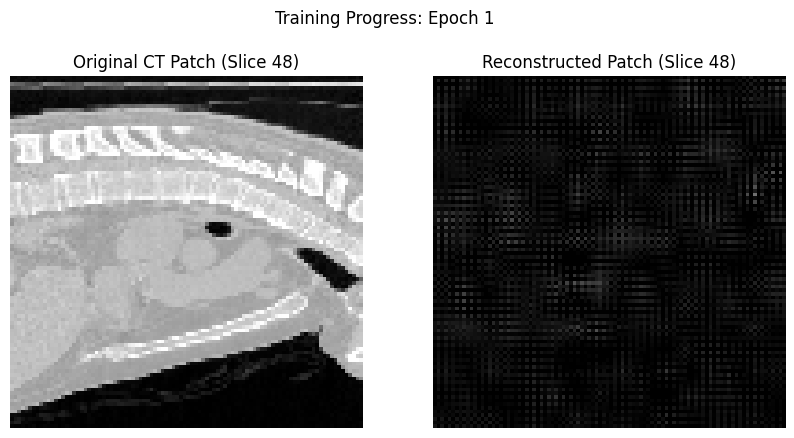

Epoch 2/50 | Average Joint Loss: 0.6750


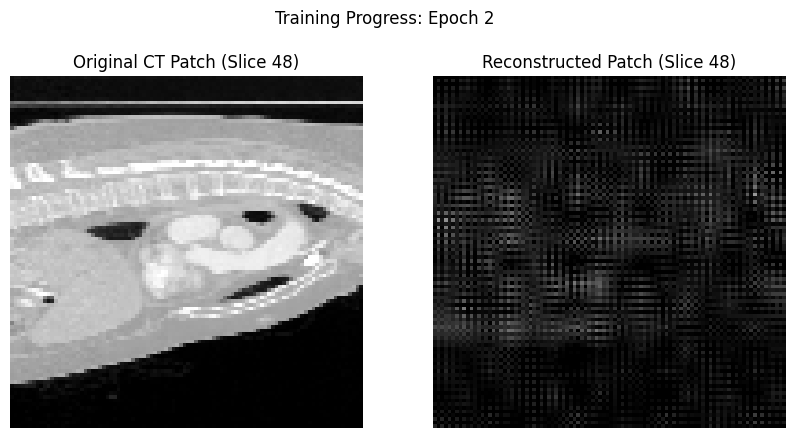

Epoch 3/50 | Average Joint Loss: 0.6547


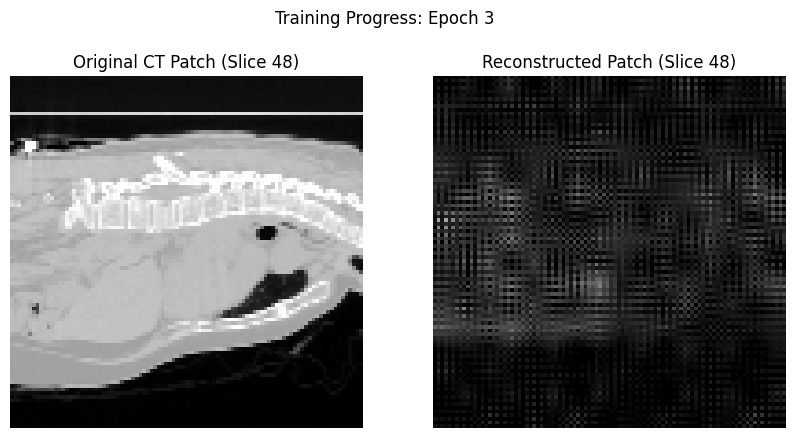

Epoch 4/50 | Average Joint Loss: 0.6365


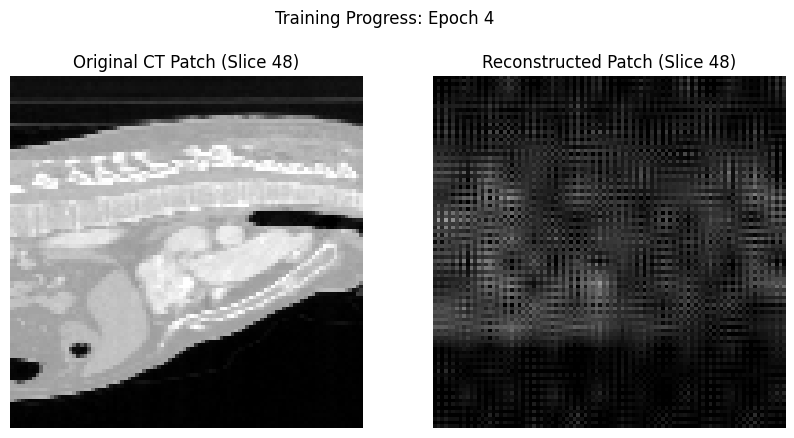

Epoch 5/50 | Average Joint Loss: 0.6365


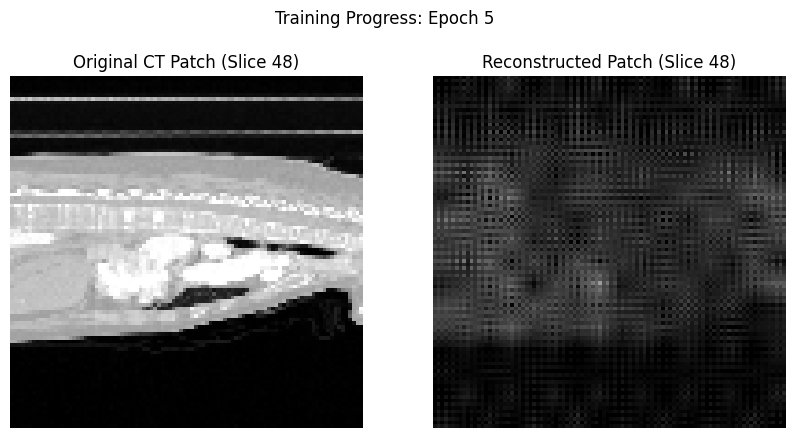

Epoch 6/50 | Average Joint Loss: 0.6251


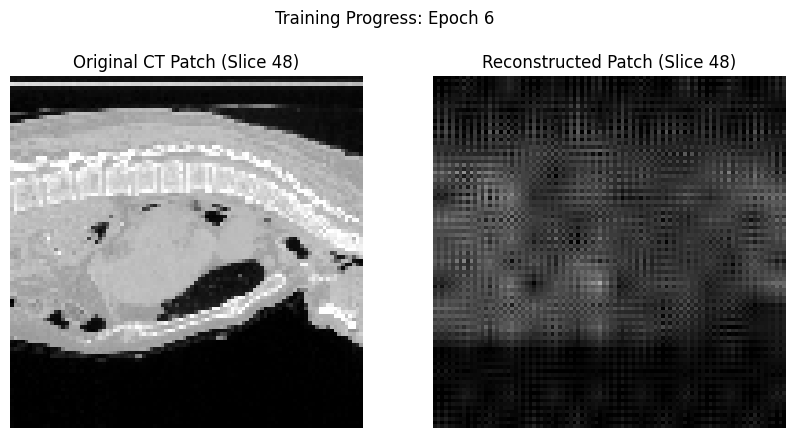

Epoch 7/50 | Average Joint Loss: 0.6214


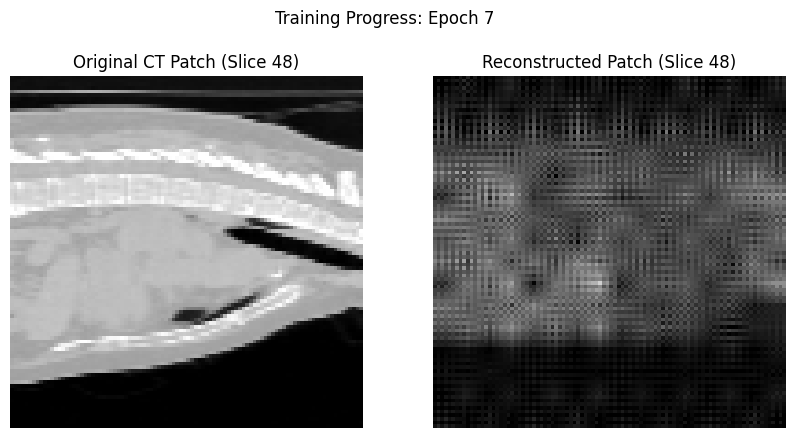

Epoch 8/50 | Average Joint Loss: 0.6068


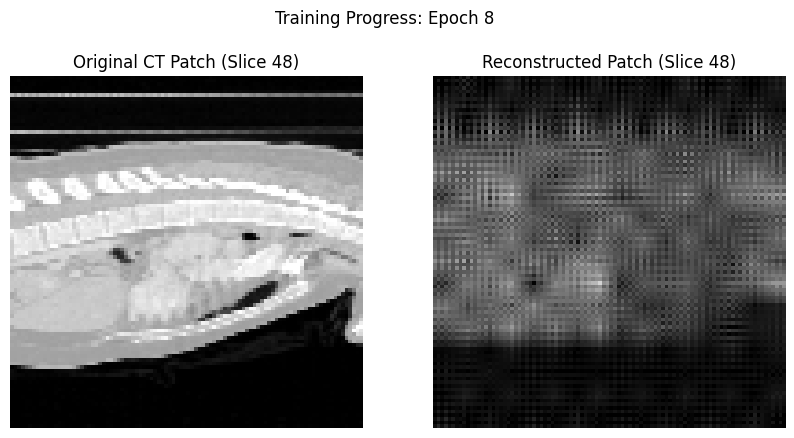

Epoch 9/50 | Average Joint Loss: 0.5934


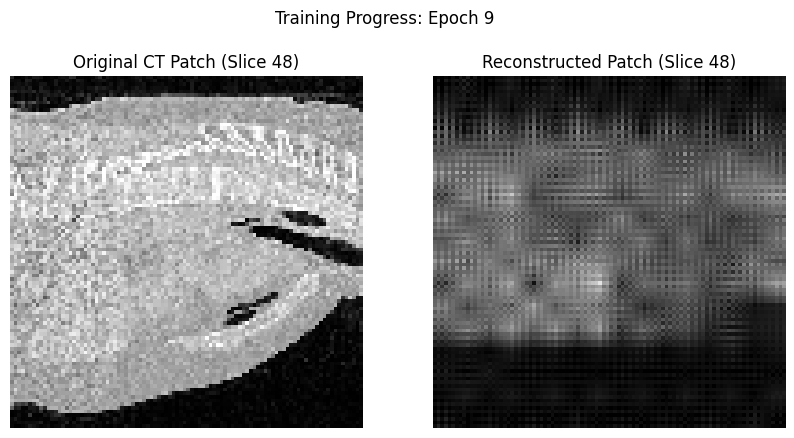

Epoch 10/50 | Average Joint Loss: 0.5892


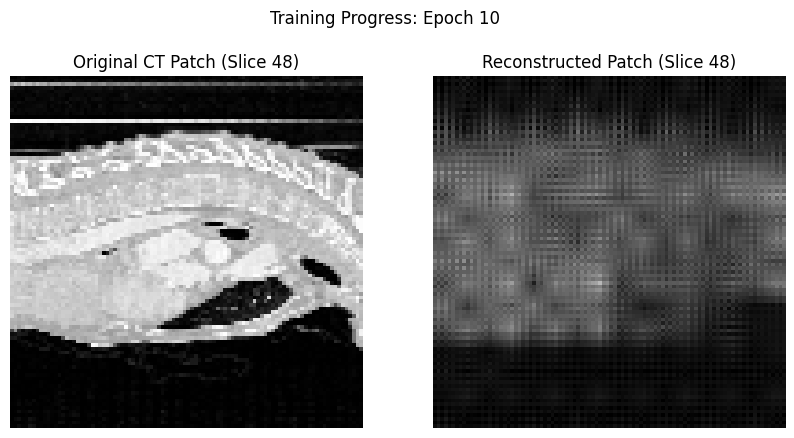

Epoch 11/50 | Average Joint Loss: 0.5769


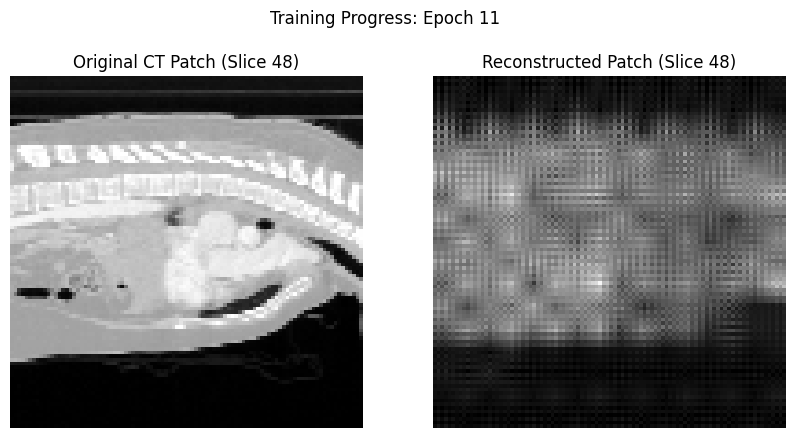

Epoch 12/50 | Average Joint Loss: 0.5736


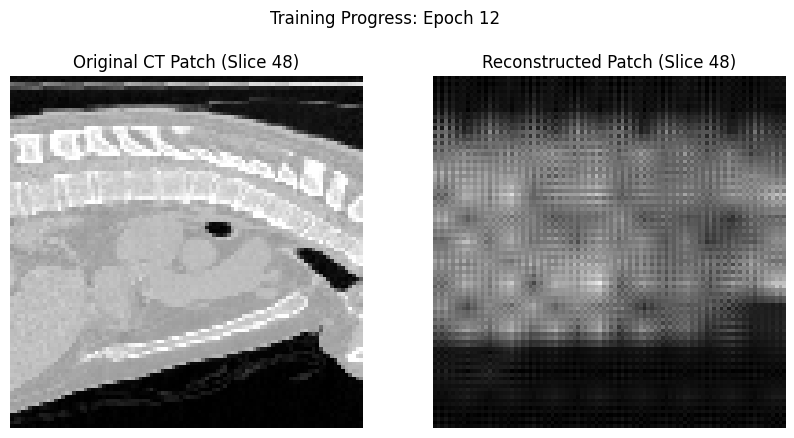

Epoch 13/50 | Average Joint Loss: 0.5754


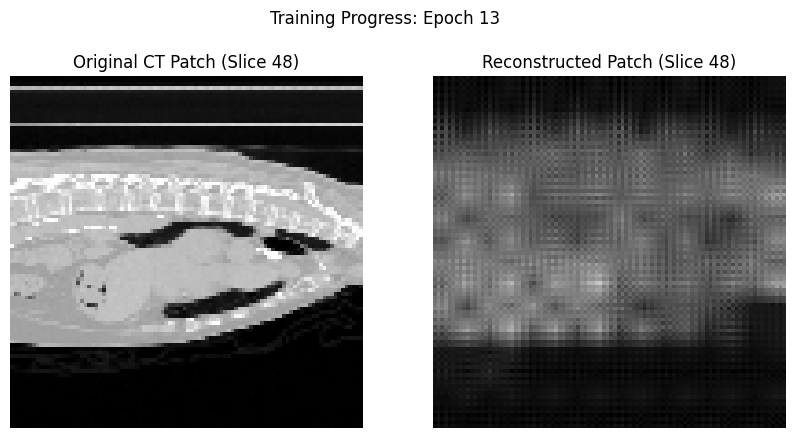

Epoch 14/50 | Average Joint Loss: 0.5581


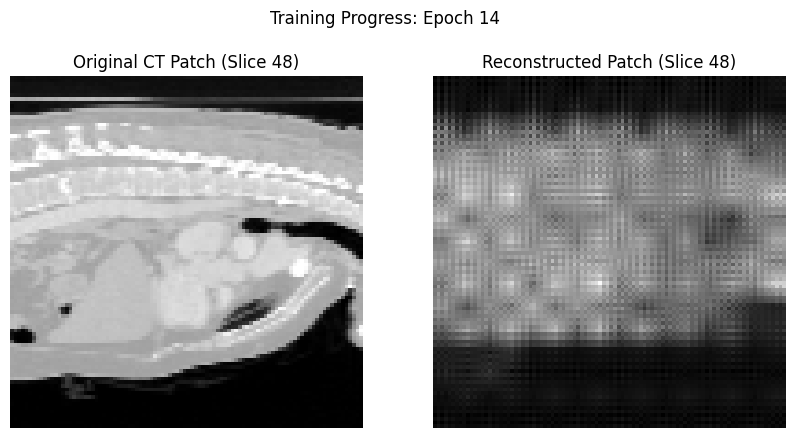

Epoch 15/50 | Average Joint Loss: 0.5640


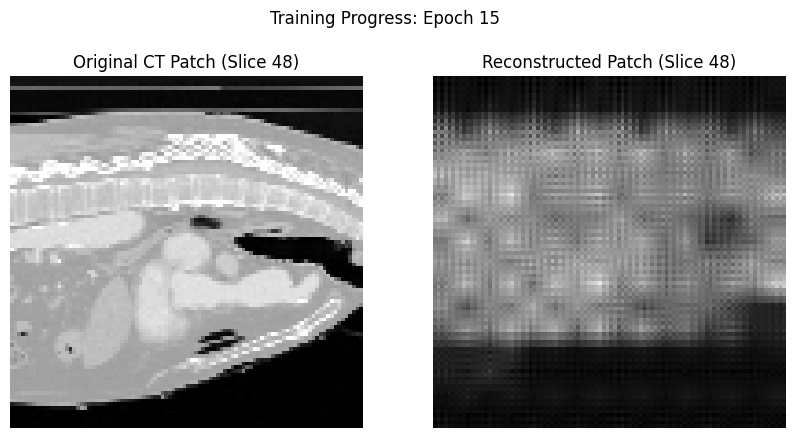

Epoch 16/50 | Average Joint Loss: 0.5577


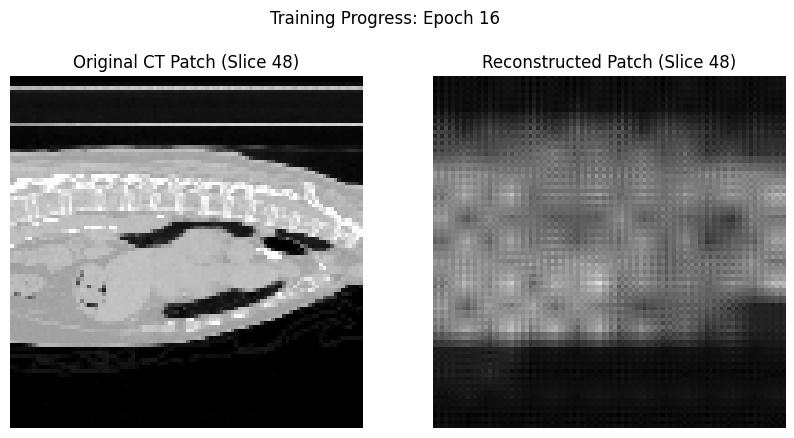

Epoch 17/50 | Average Joint Loss: 0.5582


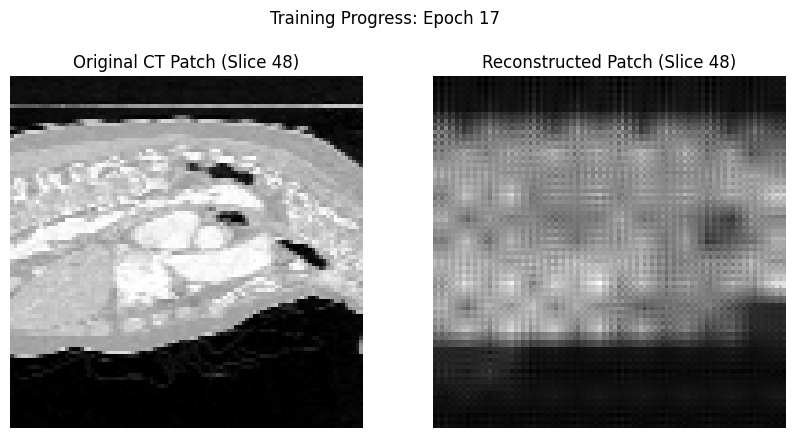

Epoch 18/50 | Average Joint Loss: 0.5487


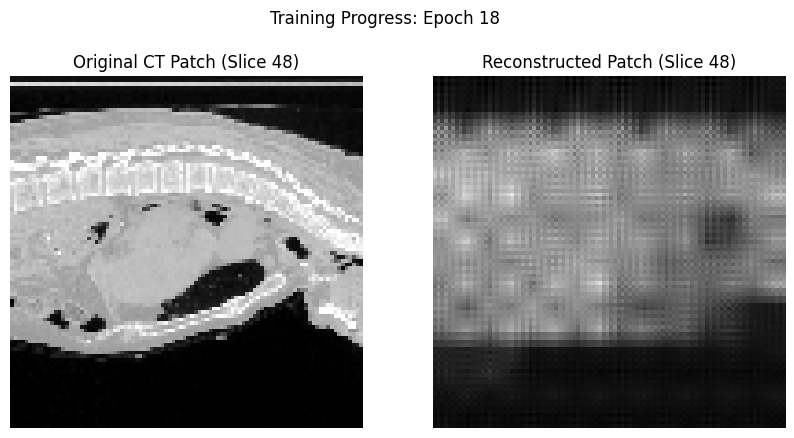

Epoch 19/50 | Average Joint Loss: 0.5519


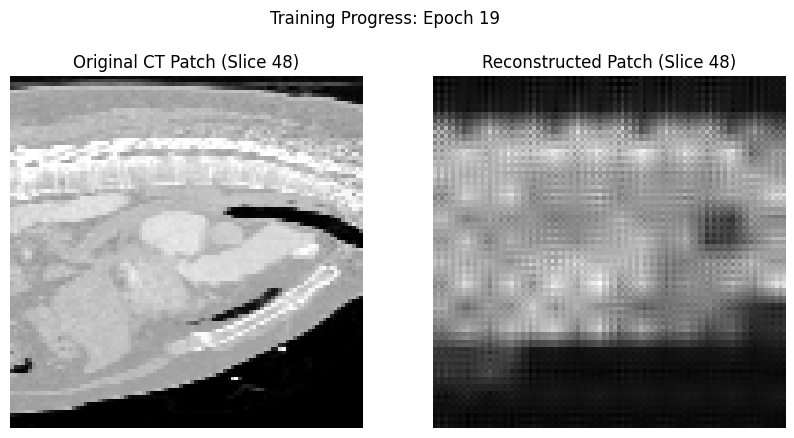

Epoch 20/50 | Average Joint Loss: 0.5429


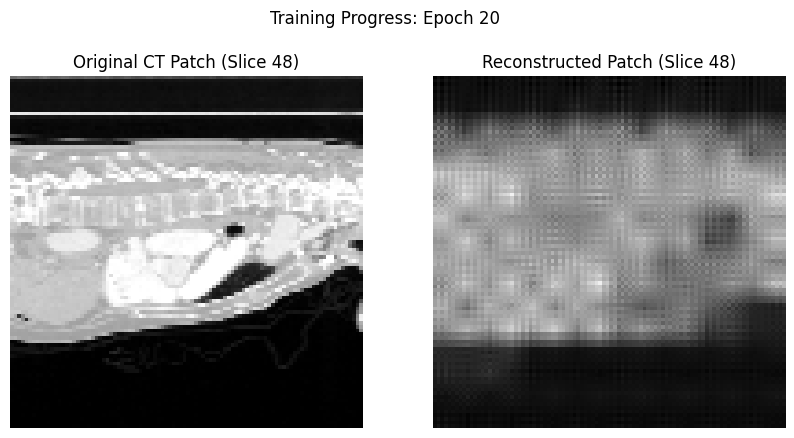

Epoch 21/50 | Average Joint Loss: 0.5431


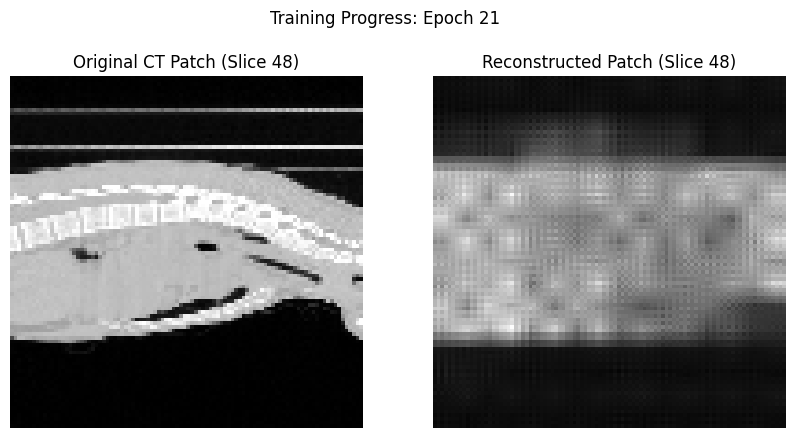

Epoch 22/50 | Average Joint Loss: 0.5434


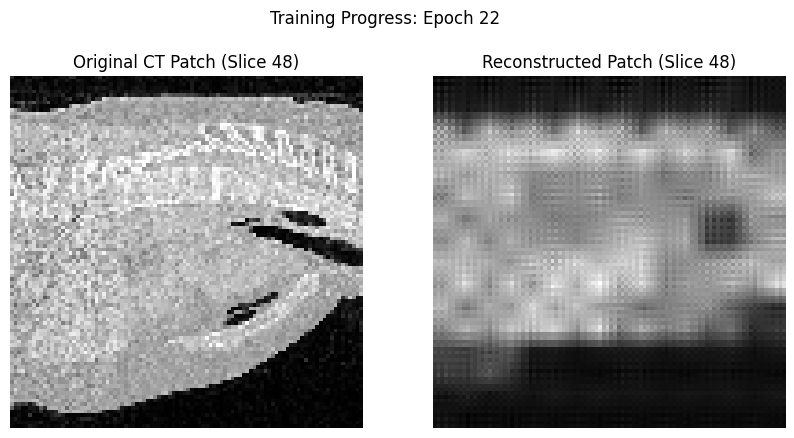

Epoch 23/50 | Average Joint Loss: 0.5396


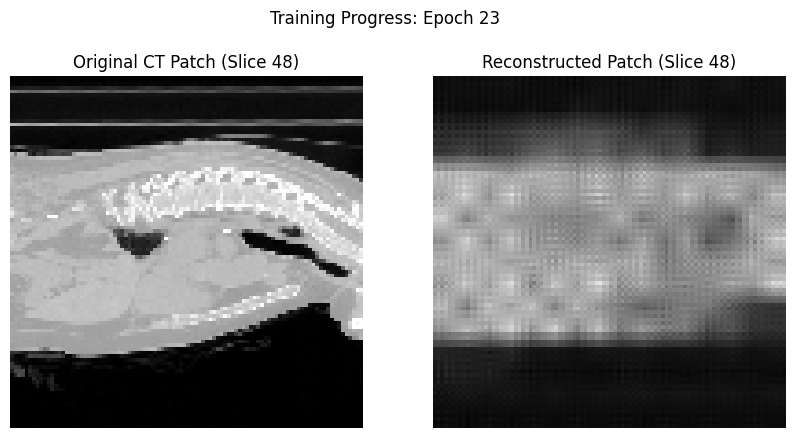

Epoch 24/50 | Average Joint Loss: 0.5437


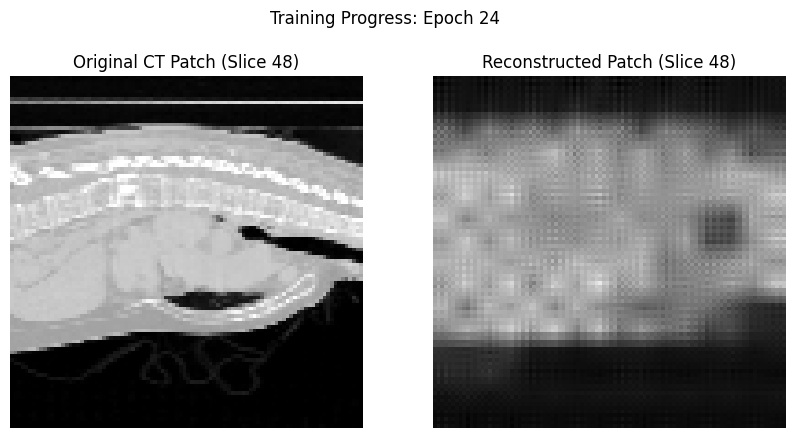

Epoch 25/50 | Average Joint Loss: 0.5381


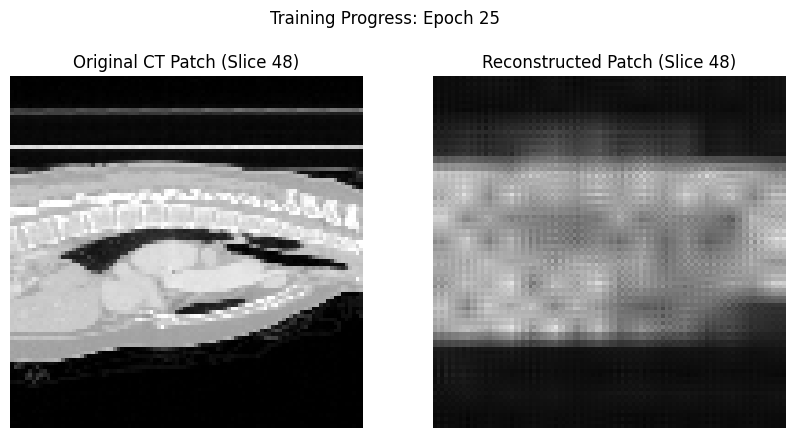

Epoch 26/50 | Average Joint Loss: 0.5327


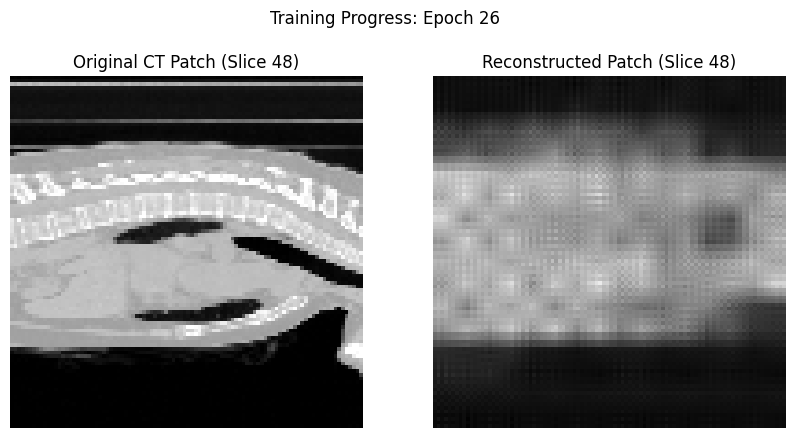

Epoch 27/50 | Average Joint Loss: 0.5299


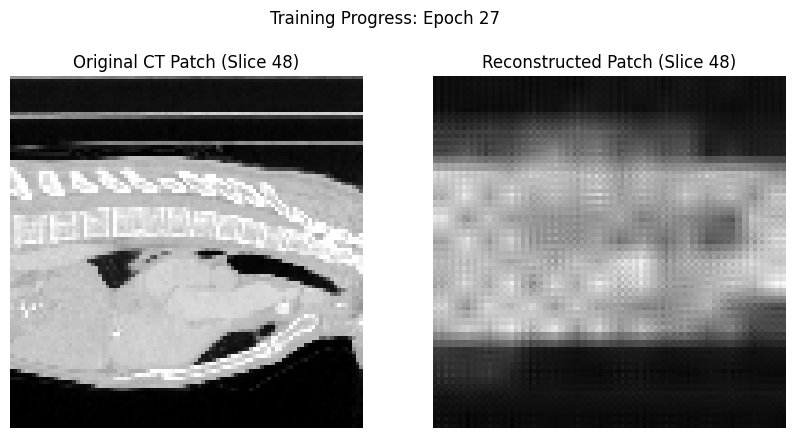

Epoch 28/50 | Average Joint Loss: 0.5305


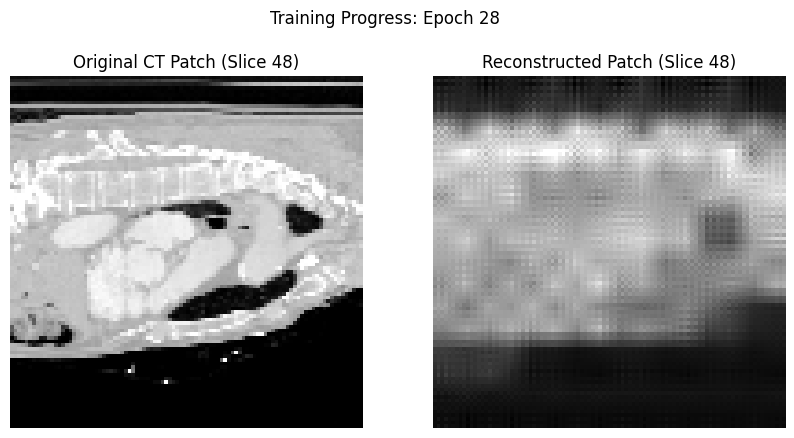

Epoch 29/50 | Average Joint Loss: 0.5338


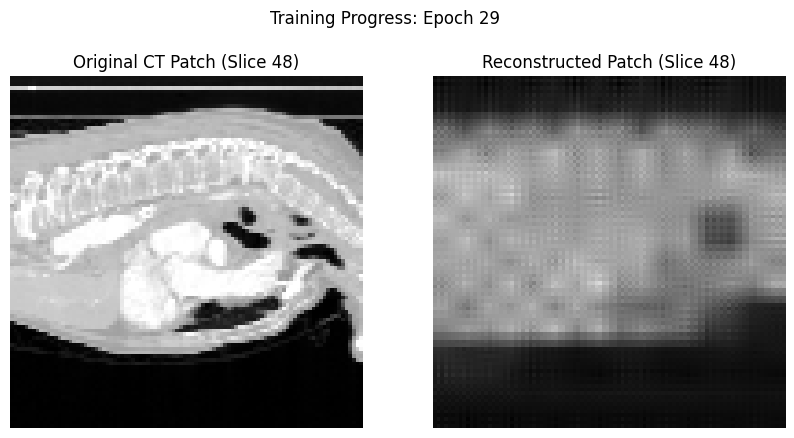

Epoch 30/50 | Average Joint Loss: 0.5244


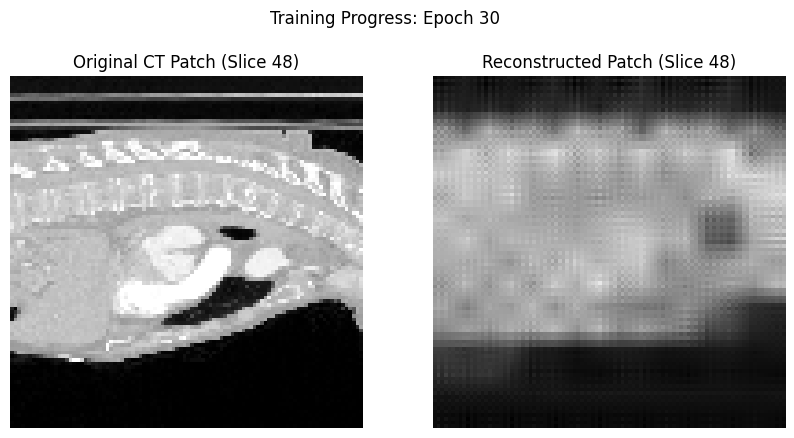

Epoch 31/50 | Average Joint Loss: 0.5286


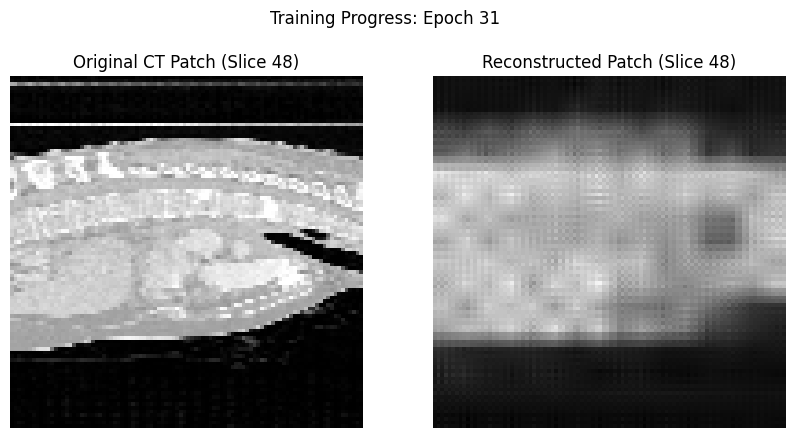

Epoch 32/50 | Average Joint Loss: 0.5273


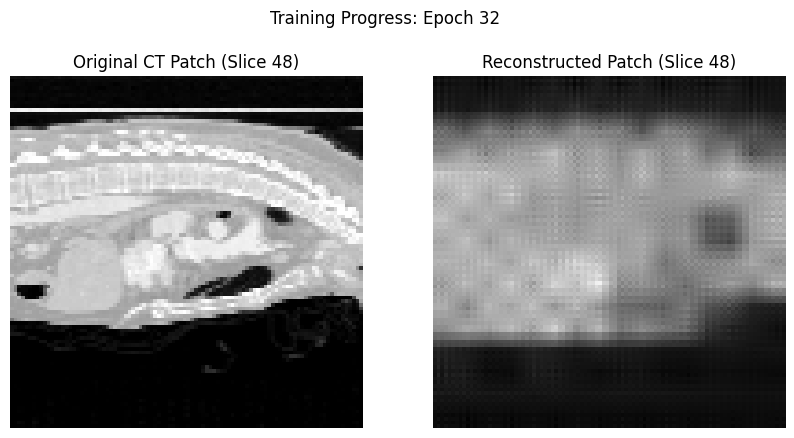

Epoch 33/50 | Average Joint Loss: 0.5246


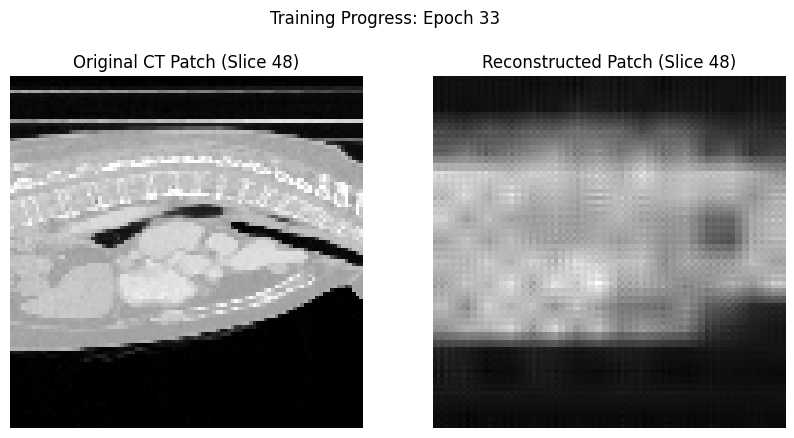

Epoch 34/50 | Average Joint Loss: 0.5091


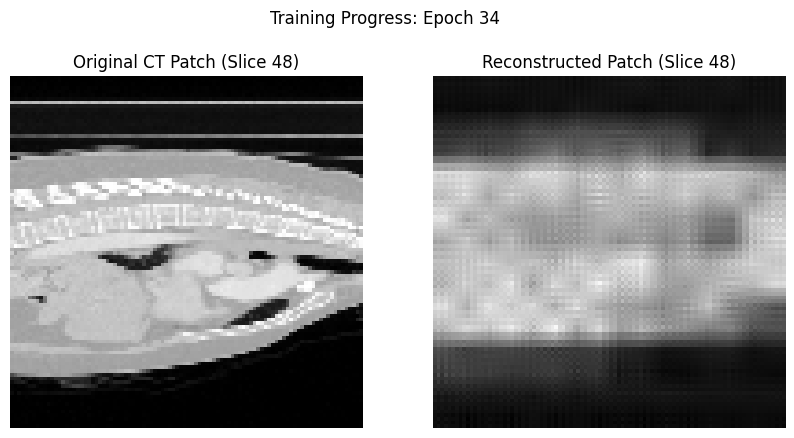

Epoch 35/50 | Average Joint Loss: 0.5166


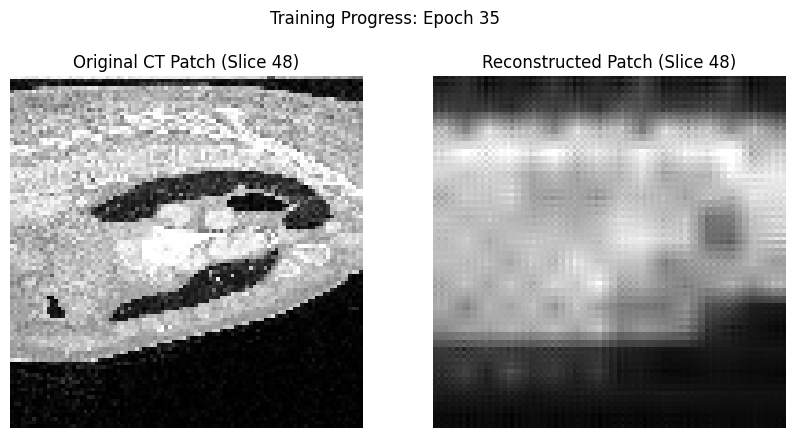

Epoch 36/50 | Average Joint Loss: 0.5065


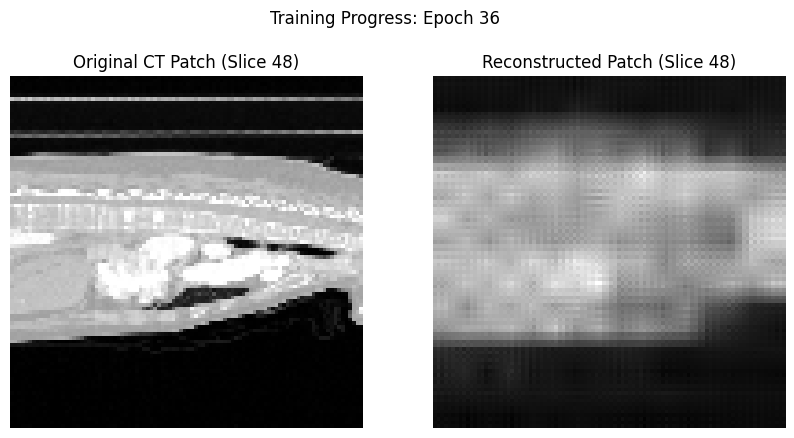

Epoch 37/50 | Average Joint Loss: 0.5073


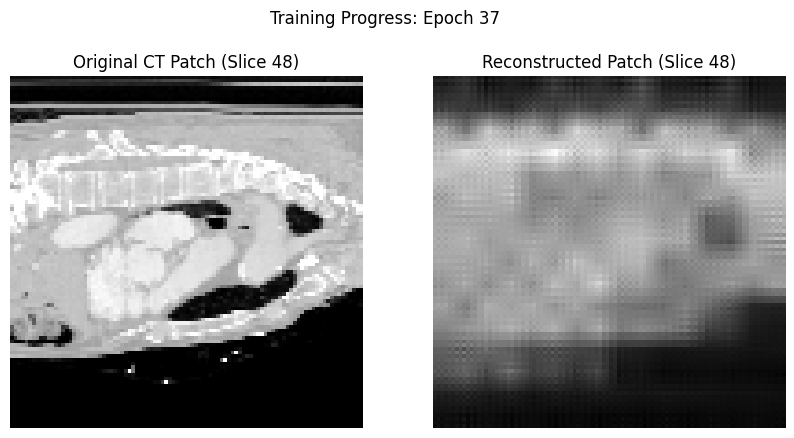

Epoch 38/50 | Average Joint Loss: 0.5042


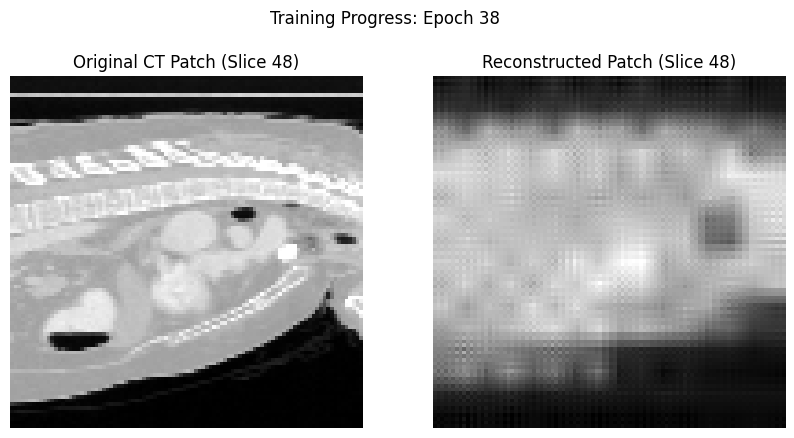

Epoch 39/50 | Average Joint Loss: 0.5047


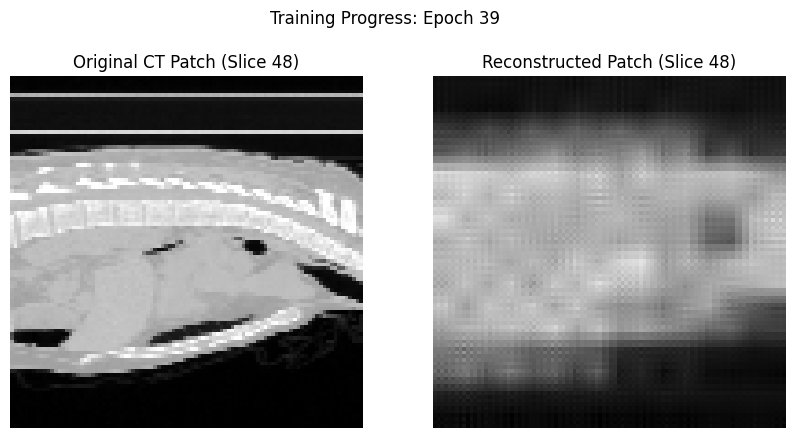

Epoch 40/50 | Average Joint Loss: 0.5097


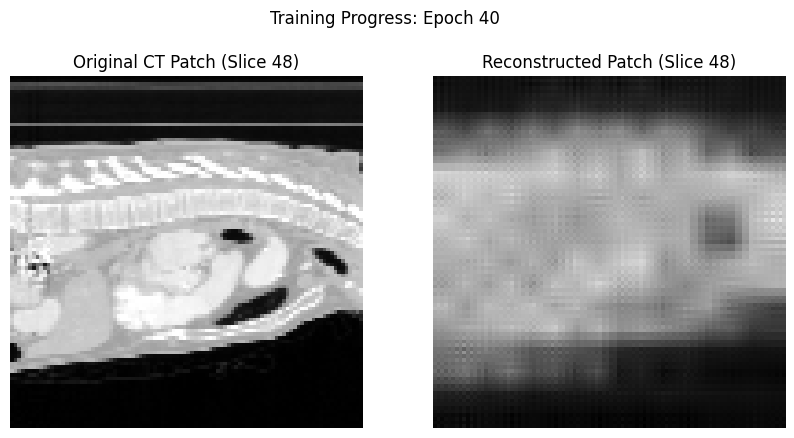

Epoch 41/50 | Average Joint Loss: 0.5072


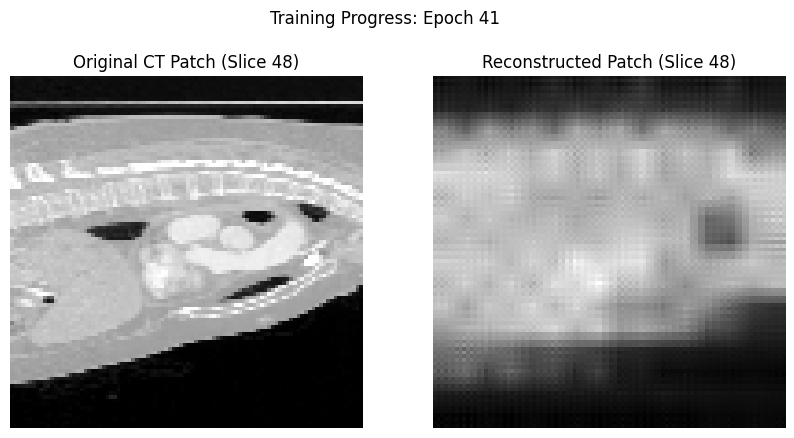

Epoch 42/50 | Average Joint Loss: 0.4955


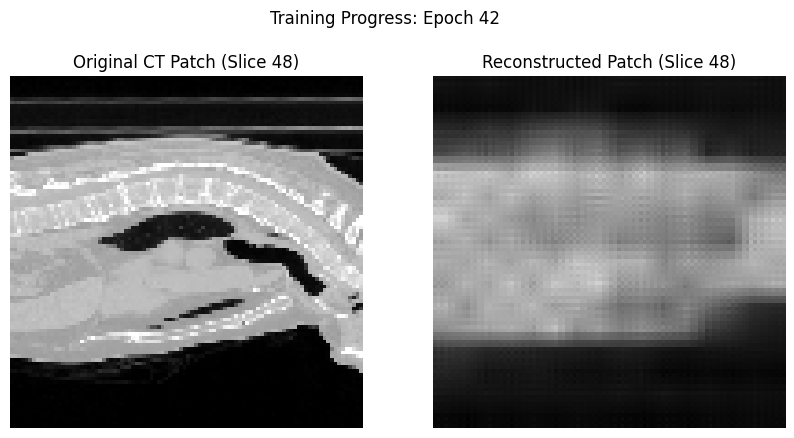

Epoch 43/50 | Average Joint Loss: 0.4960


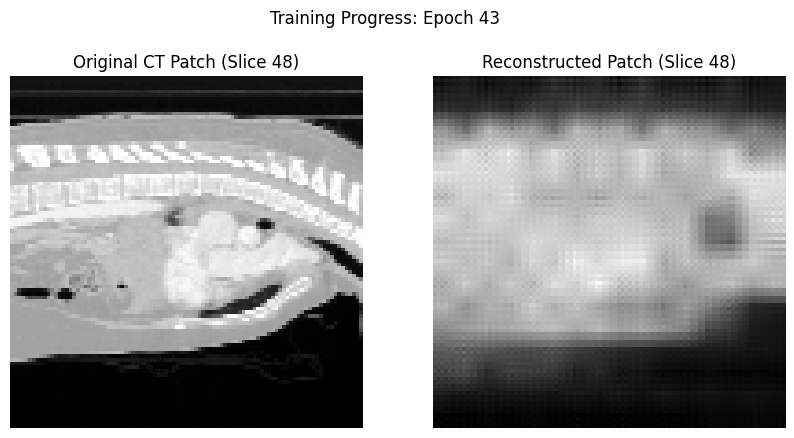

Epoch 44/50 | Average Joint Loss: 0.4897


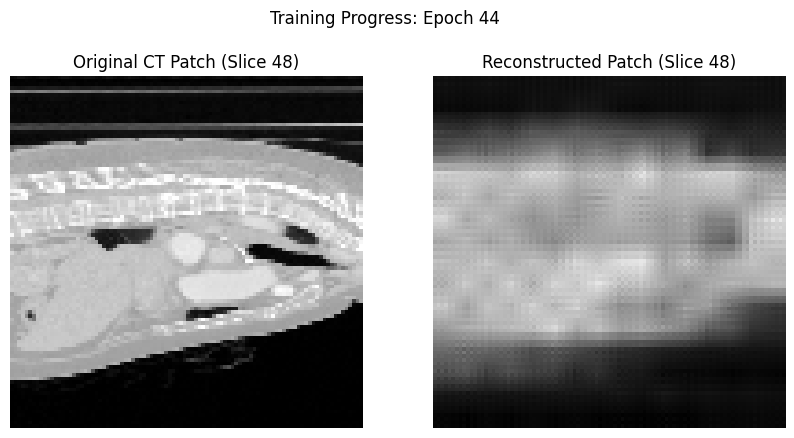

Epoch 45/50 | Average Joint Loss: 0.4902


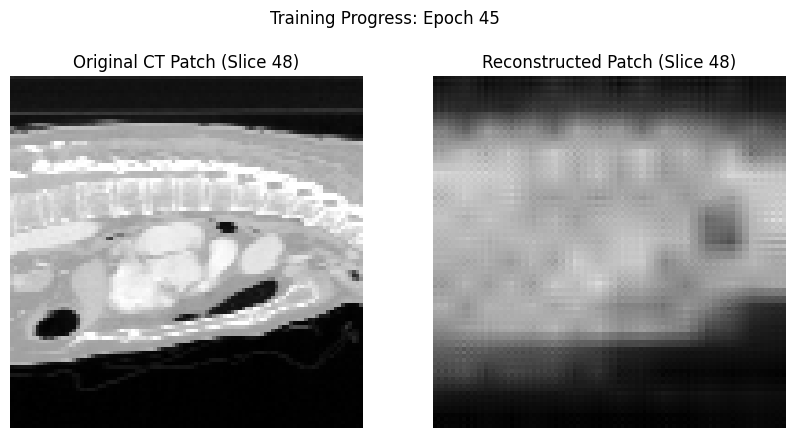

Epoch 46/50 | Average Joint Loss: 0.4926


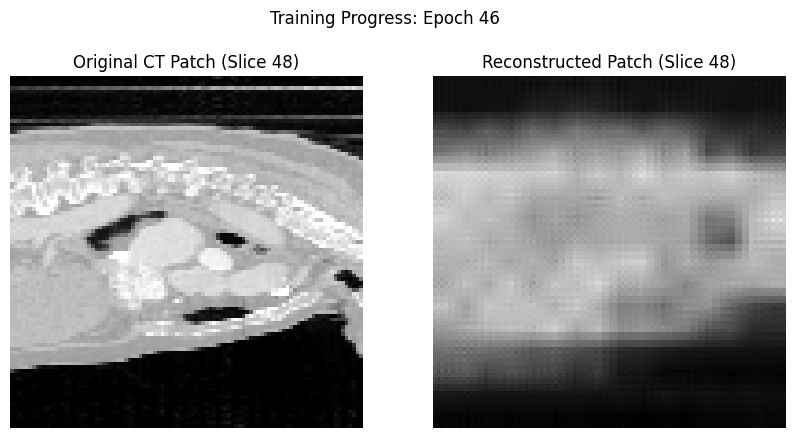

Epoch 47/50 | Average Joint Loss: 0.4900


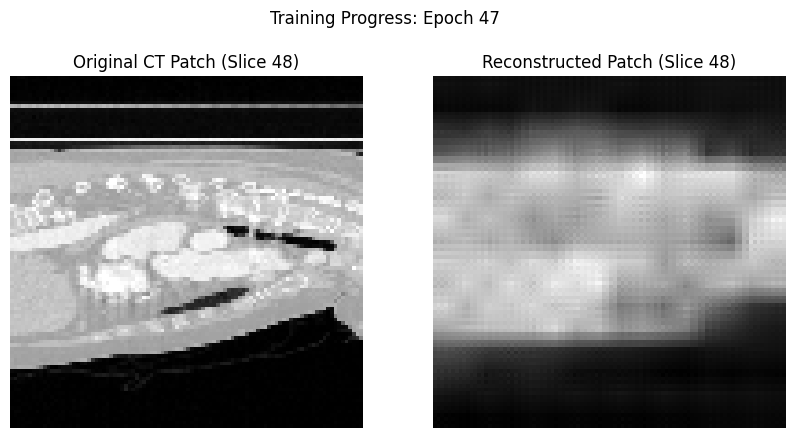

Epoch 48/50 | Average Joint Loss: 0.4883


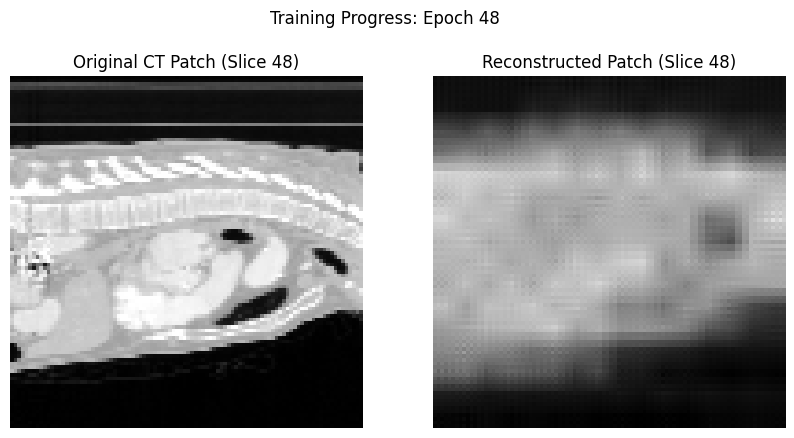

Epoch 49/50 | Average Joint Loss: 0.4855


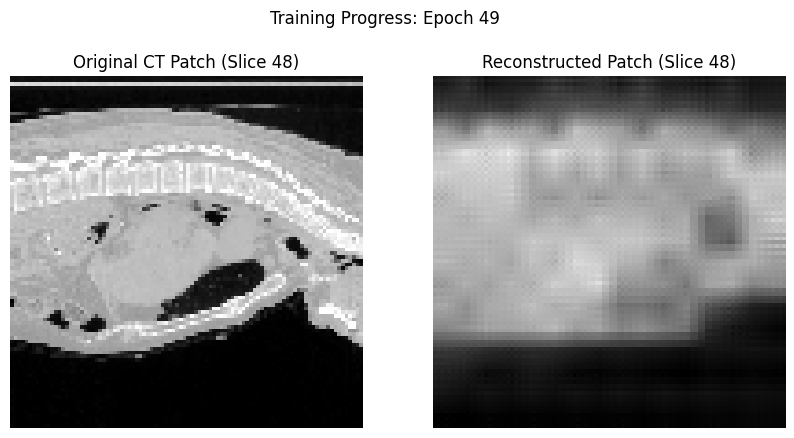

Epoch 50/50 | Average Joint Loss: 0.4924


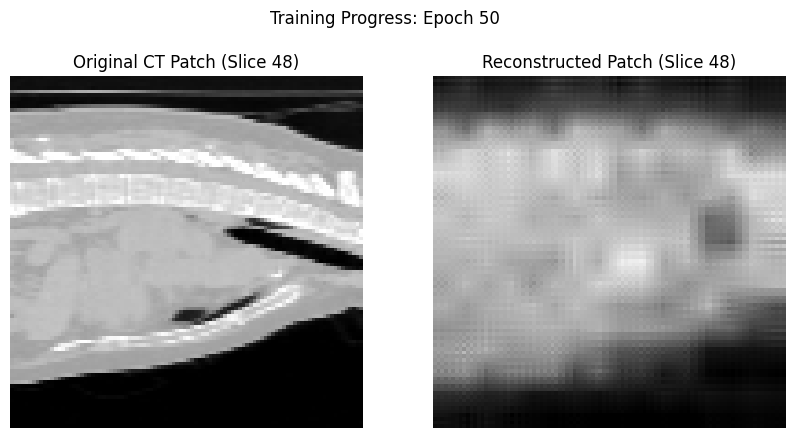

In [1]:
import os
import glob
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import pywt
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# =====================================================================
# 1. DATASET & WAVELET TRANSFORMS
# =====================================================================
class WaveletTransform3D:
    def __init__(self, wavelet='haar'):
        self.wavelet = wavelet

    def __call__(self, x):
        coeffs = pywt.dwtn(x.numpy(), self.wavelet)
        channels = [
            coeffs['aaa'], coeffs['aad'], coeffs['ada'], coeffs['add'],
            coeffs['daa'], coeffs['dad'], coeffs['dda'], coeffs['ddd']
        ]
        stacked_wavelets = np.stack(channels, axis=0)
        return torch.tensor(stacked_wavelets, dtype=torch.float32)

class InverseWaveletTransform3D:
    def __init__(self, wavelet='haar'):
        self.wavelet = wavelet

    def __call__(self, x):
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        coeffs = {
            'aaa': x[0], 'aad': x[1], 'ada': x[2], 'add': x[3],
            'daa': x[4], 'dad': x[5], 'dda': x[6], 'ddd': x[7]
        }
        reconstructed_volume = pywt.idwtn(coeffs, self.wavelet)
        return torch.tensor(reconstructed_volume, dtype=torch.float32)

class NiftiDiffusionDataset(Dataset):
    def __init__(self, nifti_dir, target_size=(96, 96, 96)):
        self.file_paths = glob.glob(os.path.join(nifti_dir, "*.nii*"))
        self.target_size = target_size
        self.wavelet_transform = WaveletTransform3D(wavelet='haar')
        
        if len(self.file_paths) == 0:
            print(f"Error: No NIfTI files found in {nifti_dir}. Check your path!")
        else:
            print(f"Dataset initialized with {len(self.file_paths)} scans from {nifti_dir}.")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load NIfTI and normalize
        nifti_img = nib.load(self.file_paths[idx])
        volume = nifti_img.get_fdata(dtype=np.float32)
        
        # Normalize HU values to [0, 1]
        volume = np.clip(volume, -1000, 400)
        volume = (volume - (-1000)) / (400 - (-1000))
        
        # Resize to 96x96x96 for the Lite-LDM patch requirement
        tensor_vol = torch.tensor(volume).unsqueeze(0).unsqueeze(0)
        tensor_vol = F.interpolate(tensor_vol, size=self.target_size, mode='trilinear', align_corners=False)
        tensor_vol = tensor_vol.squeeze()
        
        # Transform to Wavelet domain: output shape (8, 48, 48, 48)
        return self.wavelet_transform(tensor_vol)

# =====================================================================
# 2. LITE-LDM MODELS
# =====================================================================
class WaveletEncoder3D(nn.Module):
    def __init__(self, in_channels=8, latent_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(in_channels, 16, 3, padding=1), nn.BatchNorm3d(16), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(16, 32, 3, padding=1), nn.BatchNorm3d(32), nn.ReLU(), nn.MaxPool3d(2),
            nn.Conv3d(32, 64, 3, padding=1), nn.BatchNorm3d(64), nn.ReLU(), nn.MaxPool3d(2),
            nn.AdaptiveAvgPool3d((2, 2, 2))
        )
        self.dropout = nn.Dropout(p=0.2)
        self.fc = nn.Linear(64 * 2 * 2 * 2, latent_dim)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x) 
        return self.fc(x)

class WaveletDecoder3D(nn.Module):
    def __init__(self, latent_dim=256, out_channels=8):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 2 * 2 * 2)
        self.dropout = nn.Dropout(p=0.2)
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2), nn.BatchNorm3d(32), nn.ReLU(),
            nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2), nn.BatchNorm3d(16), nn.ReLU(),
            nn.ConvTranspose3d(16, out_channels, kernel_size=2, stride=2),
        )

    def forward(self, z):
        x = self.fc(z)
        x = self.dropout(x)
        x = x.view(-1, 64, 2, 2, 2)
        x_hat = self.decoder(x) 
        x_hat = F.interpolate(x_hat, size=(48, 48, 48), mode='trilinear', align_corners=False)
        return x_hat

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        return torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)

class LatentDiffusionDenoiser(nn.Module):
    def __init__(self, latent_dim=256, time_emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim), nn.ReLU()
        )
        self.net = nn.Sequential(
            nn.Linear(latent_dim + time_emb_dim, 512), nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, latent_dim)
        )

    def forward(self, z, time):
        t_emb = self.time_mlp(time)
        z_t_combined = torch.cat([z, t_emb], dim=1)
        return self.net(z_t_combined)

# =====================================================================
# 3. VISUALIZATION & TRAINING
# =====================================================================
def visualize_3d_slices(original_vol, generated_vol, slice_idx=48, epoch=0):
    if isinstance(original_vol, torch.Tensor): original_vol = original_vol.detach().cpu().numpy()
    if isinstance(generated_vol, torch.Tensor): generated_vol = generated_vol.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_vol[slice_idx, :, :], cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f"Original CT Patch (Slice {slice_idx})")
    axes[0].axis('off')

    axes[1].imshow(generated_vol[slice_idx, :, :], cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Reconstructed Patch (Slice {slice_idx})")
    axes[1].axis('off')

    plt.suptitle(f"Training Progress: Epoch {epoch}")
    plt.show()

def train_lite_ldm(dataset, epochs=50, batch_size=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")

    encoder = WaveletEncoder3D(latent_dim=256).to(device)
    decoder = WaveletDecoder3D(latent_dim=256).to(device)
    diffusion = LatentDiffusionDenoiser(latent_dim=256).to(device)
    inverse_transformer = InverseWaveletTransform3D(wavelet='haar')

    all_parameters = list(encoder.parameters()) + list(decoder.parameters()) + list(diffusion.parameters())
    optimizer = torch.optim.AdamW(all_parameters, lr=1e-4, weight_decay=1e-5)
    mse_loss = nn.MSELoss()

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

    for epoch in range(1, epochs + 1):
        encoder.train()
        decoder.train()
        diffusion.train()
        epoch_loss = 0.0

        for batch_idx, wavelet_real in enumerate(dataloader):
            wavelet_real = wavelet_real.to(device)
            current_batch_size = wavelet_real.size(0)
            optimizer.zero_grad()

            # A. Autoencoder Pass
            z_latent = encoder(wavelet_real)
            wavelet_reconstructed = decoder(z_latent)
            loss_ae = mse_loss(wavelet_reconstructed, wavelet_real)

            # B. Diffusion Pass
            noise = torch.randn_like(z_latent).to(device)
            timesteps = torch.randint(0, 1000, (current_batch_size,)).to(device)
            noise_level = (timesteps / 1000.0).unsqueeze(1)
            
            z_noisy = (1 - noise_level) * z_latent + noise_level * noise
            predicted_noise = diffusion(z_noisy, timesteps)
            loss_diff = mse_loss(predicted_noise, noise)

            # C. Joint Optimization
            total_loss = loss_ae + (0.5 * loss_diff)
            total_loss.backward()
            optimizer.step()
            epoch_loss += total_loss.item()

        print(f"Epoch {epoch}/{epochs} | Average Joint Loss: {epoch_loss/len(dataloader):.4f}")

        # Visualization at the end of the epoch
        encoder.eval()
        decoder.eval()
        with torch.no_grad():
            sample_wavelet = wavelet_real[0].unsqueeze(0)
            sample_latent = encoder(sample_wavelet)
            sample_recon_wavelet = decoder(sample_latent)
            
            orig_3d_img = inverse_transformer(sample_wavelet.squeeze(0))
            recon_3d_img = inverse_transformer(sample_recon_wavelet.squeeze(0))
            
            visualize_3d_slices(orig_3d_img, recon_3d_img, slice_idx=48, epoch=epoch)

# =====================================================================
# 4. EXECUTION
# =====================================================================
if __name__ == "__main__":
    nifti_folder = './nifti' 
    
    # Initialize the dataset using the NIfTI files
    print("Loading NIfTI files into dataset...")
    real_dataset = NiftiDiffusionDataset(nifti_dir=nifti_folder, target_size=(96, 96, 96))
    
    if len(real_dataset) > 0:
        print("Starting Lite-LDM Training...")
        # Start training
        train_lite_ldm(real_dataset, epochs=50, batch_size=2)
    else:
        print("Training aborted: No data found in the specified directory.")